# Multivariate Modelling of Censored Chemicals using jsdmstan

{bdg-link-info}`Notebook Repository <https://github.com/NERC-CEH/ds-toolbox-notebook-jsdm-censor.git>`
{bdg-link-info}`Method Repository <https://github.com/NERC-CEH/jsdmstan.git>`
![alt text](./images/ukceh-logo-badge.png "Title")

Primary Contact: [Dr. Fiona Seaton](https://www.ceh.ac.uk/staff/fiona-seaton)

````{card} Challenge:
Water quality data often occurs in subsets of closely-related chemicals, that can be expected to correlate in their strength. Notable examples include per- and polyfluoroalkyl substances (PFAS), which are of ever-increasing policy and public relevance. Generally, statistical modelling of these chemicals is done one chemical at a time. However, it is possible that multivariate modelling techniques, which would allow information to be shared between different chemicals, could lead to more accurate predictions of chemical concentrations for both the individual chemicals and the entire family group.

Multivariate modelling of water quality chemicals is particularly relevant due to the presence of censoring, i.e. measurements fall above or below the limit of detection. While laboratory methods are ever-improving, there are still often chemical measurements that fall outside the measurement limits. And if we are to compare across longer periods of time we must account for changing limits of detection. In theory, multivariate modelling could allow the concentration of a more abundant chemical to inform the prediction of a chemical below the limit of detection.
`````

````{card} Approach:
In practice, most traditional multivariate modelling techniques are less able to cope with the censoring and complex structures present within water quality datasets. However, a potential option is the application of the joint species distribution modelling (JSDM) framework adopted recently in ecology ([Warton et al., 2015](https://doi.org/10.1016/j.tree.2015.09.007)). This framework models multiple species simultaneously, taking account of their co-occurrence and response to environmental covariates, and allows for a wide variety of potential response families. The existing methods for JSDMs, however, do not allow for either left-censoring or lognormal distributions due to the focus on species-type data.

Here we present the results of extending the JSDM approach within the `jsdmstan` package to include left-censoring and non-linear environmental effects. The `jsdmstan` package is an R package that allows the fitting of JSDMs within Stan, a probabilistic programming language for fitting Bayesian models using a variant of Hamiltonian Monte Carlo ([Carpenter et al., 2017](https://doi.org/10.18637/jss.v076.i01), [Stan website](https://mc-stan.org/), [Seaton, 2025](https://doi.org/10.1101/2025.11.10.687559), [jsdmstan website](https://nerc-ceh.github.io/jsdmstan/)). We provide here a brief introduction to the JSDM framework, plus explanation of the extension to left-censoring and non-linear effects, then illustrate these models using two case studies. This first case study is a model of per- and polyfluoroalkyl substances (PFAS) chemicals and the second a model of polycyclic aromatic hydrocarbons (PAH) chemicals.
`````

In [1]:
library(jsdmstan)
library(dplyr)
library(tidyr)
library(lubridate)
library(ggplot2)
library(patchwork)
library(sf)
gbr <- st_read("Data/gbr.shp")
theme_set(theme_classic())
set.seed(1113156)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'tidyr'


The following object is masked from 'package:jsdmstan':

    extract



Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union


Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE



Reading layer `gbr' from data source 
  `C:\Users\jercar\OneDrive - UKCEH\VSCode\data-science-toolbox\methods\ds-toolbox-notebook-jsdm-censor\Data\gbr.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 4 features and 9 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -13.69139 ymin: 49.86542 xmax: 1.764168 ymax: 61.52708
Geodetic CRS:  WGS 84


# Introduction

Water quality data often occurs in subsets of closely-related chemicals, that can be expected to correlate in their strength. Notable examples
include per- and polyfluoroalkyl substances (PFAS), which are of ever-increasing policy and public relevance. Generally, statistical modelling of these chemicals is done one chemical at a time. However, it is possible that multivariate modelling techniques, which would allow information to be shared between different chemicals, could lead to more accurate predictions of chemical concentrations for both the individual chemicals and the entire family group.

Multivariate modelling of water quality chemicals is particularly relevant due to the presence of censoring, i.e. measurements fall above or below the limit of detection. While laboratory methods are ever-improving, there are still often chemical measurements that fall outside the measurement limits. And if we are to compare across longer periods of time we must account for changing limits of detection. In theory, multivariate modelling could allow the concentration of a more abundant chemical to inform the prediction of a chemical below the limit of detection.

In practice, most traditional multivariate modelling techniques are less able to cope with the censoring and complex structures present within water quality datasets. However, a potential option is the application of the joint species distribution modelling (JSDM) framework adopted recently in ecology ([Warton et al., 2015](https://doi.org/10.1016/j.tree.2015.09.007)). This framework models multiple species simultaneously, taking account of their co-occurrence and response to environmental covariates, and allows for a wide variety of potential response families. The existing methods for JSDMs, however, do not allow for either left-censoring or lognormal distributions due to the focus on species-type data.

Here we present the results of extending the JSDM approach within the `jsdmstan` package to include left-censoring and non-linear environmental effects. The `jsdmstan` package is an R package that allows the fitting of JSDMs within Stan, a probabilistic programming language for fitting Bayesian models using a variant of Hamiltonian Monte Carlo ([Carpenter et al., 2017](https://doi.org/10.18637/jss.v076.i01), [Stan website](https://mc-stan.org/), [Seaton, 2025](https://doi.org/10.1101/2025.11.10.687559), [jsdmstan website](https://nerc-ceh.github.io/jsdmstan/)). We provide here a brief introduction to the JSDM framework, plus explanation of the extension to left-censoring and non-linear effects, then illustrate these models using two case studies. This first case study is a model of per- and polyfluoroalkyl substances (PFAS) chemicals and the second a model of polycyclic aromatic hydrocarbons (PAH) chemicals.

# Methodology

## Joint Species Distribution Modelling

Joint Species Distribution Modelling (JSDM) is a technique that can be used to model multiple species simultaneously. Every JSDM models the species community matrix as a function of both the environmental covariates and the species-by-species relationship matrix. Where this differs from modelling data as multivariate normal is that the species-by-species relationships are represented within the linear predictor. This means that there are a much wider range of response families and model functions that can be accounted for within the JSDM framework.

We model the community data $m_{ij}$ for each site $i$ and taxon $j$ as a function of a species intercept, environmental covariates and species covariance matrix:

$$ g(m_{ij}) = \beta_{0j} + \mathbf{x}_i^\intercal\beta_j + u_{ij} $$

where $g(\cdot)$ is the link function, $\mathbf{x}_i^\intercal$ is the transpose of vector $\mathbf{x}$, and for each taxon $j$, $\beta_{0j}$ is an intercept and $\beta_{j}$ is a vector of regression coefficients related to measured predictors.

A site effect $\alpha_{i}$ can also be added to allow for effects that are consistent across sites. This can be modelled as a site-specific intercept, a site-specific random effect, or with the non-linear model extensions mentioned in the flexible effects section below:

$$ g(m_{ij}) = \alpha_{i} + \beta_{0j} + \mathbf{x}_i^\intercal\beta_j + u_{ij} $$

### Multivariate Generalised Linear Mixed Models

The entire matrix of covariance between species is modelled in MGLMMs.

$$ u_{ij} \sim \mathrm{N}(\mathbf{0},\mathbf{\Sigma}) $$

Fitting the entire covariance matrix means that the amount of time required to fit these models scales with the number of species cubed, and the data required scales with the number of species squared. This makes these models both computationally and data intensive, particularly as the number of species increases.

### Generalised Linear Latent Variable Models

In response to some of the computational issues in fitting MGLMMs to many species, GLLVMs were developed in which $u_{ij}$ is now specified as a linear function of a set of latent variables $\mathbf{z_i}$:

$$ y_{ij}|\mathbf{u}_i \sim \mathrm{F}(m_{ij},\phi_j) $$
$$ u_{ij} = \mathbf{z}_i^\intercal \lambda_j $$

The latent variables $\mathbf{z_i}$ are treated as random by assuming:

$$y_{ij}|\mathbf{z_i} \sim \mathrm{F}(m_{ij},\phi_j) $$
$$\mathbf{z_i} \sim \mathrm{N}(\mathbf{0},\mathbf{1}) $$

Treating the species covariance as pulling from a set of latent variables greatly reduces the computational time required to fit these models.

### Normal and lognormal responses

Within the link function for the normal and lognormal families the sigma parameter is modelled as a constant across all species, which is different from the case in other families with shape parameters (e.g. the negative binomial). This is necessary because of the high flexibility of the species-covariance matrix, which can within the Gaussian context lead to the model being unable to fit if there are also species-specific sigma parameters. This does not mean that the measured species variance is constrained to be identical, as the species variance within the species-covariance matrix propagates to the overall species variance. This can be shown using the data simulation functions within `jsdmstan`.

## Censored Response Modelling

Censored data occurs when we know the limit of the measurement but not the true value. This is particularly common within water quality measurements, where the laboratory method may only be able to determine the true value within a certain range and for anything above or below that range returns a censored value. Left-censoring occurs when the true value is below the lower limit-of-detection, while right-censoring occurs when the true value is above the upper limit-of-detection. Within the jsdmstan package we can model left-censored data.

Modelling left-censored data can be done by combining a standard probability density-based model for the uncensored measurements with a cumulative density-based model for the left-censored measurements. The model does not need to impute the values directly, but instead integrates them out as described in the [Stan’s User Guide](https://mc-stan.org/docs/stan-users-guide/truncation-censoring.html#integrating-out-censored-values). Within the multivariate context in Stan code, this involves some fancy indexing, but in general follows the following pattern:

    for (s in 1:S){
      target += normal_lpdf(Y[uncensored] | mu[uncensored], sigma)
      target += normal_lcdf(Y[censored] | mu[censored], sigma)
    }

Note that within jsdmstan left-censoring is currently only implemented for Gaussian/normal, lognormal, and gamma families. The gamma family is also still experimental and not fully tested yet, so in practice the lognormal or normal distributions should be used.

## Fitting flexible effects (splines and random effects)

Though we can use the standard regression “fixed effects” like intercepts and slopes to describe features in the data, sometimes these are not enough and we require more flexible terms in our models.

Splines and random effects can be included to allow functions of the covariates that are more flexible and random effects can be used to include blocking structures and heterogeneity in the samples.

Within `jsdmstan`, it is now possible to fit spline effects at the site/measurement level. This is facilitated by a link to the [`mgcv`](https://cran.r-project.org/package=mgcv) package’s function for setting-up such models. `jsdmstan` now supports all types of splines supported by `s()` (see [this manual page for more information](https://cran.r-project.org/web/packages/mgcv/refman/mgcv.html#smooth.terms) and see also [the random effects in `mgcv` help page](https://cran.r-project.org/web/packages/mgcv/refman/mgcv.html#random.effects). (Not all basis functions have been tested yet.) It is also now possible to fit a factor-smooth that varies by species (or water quality chemical, in this case; see [Pedersen et al 2019](http://doi.org/10.7717/peerj.6876) for more information on this formulation).

To fit this model as part of `jsdmstan` we utilize the connections between smoothers and Bayesian methods (see [Miller (2025)](https://doi.org/10.1111/2041-210X.14498) and references therein). We can write our flexible functions as a sum of basis functions:

$$
s(x) = \sum_{k=1}^K \beta_k b_k(x)
$$

where $b_k(x)$ are $K$ simple basis functions which are added-up to create the model complicated $s(x)$ term. Each basis function is scaled by a parameter ($\beta_k$) to be estimated during fitting. To avoid overfitting (since these models can be very flexible. We impose a prior on the $\beta_k$s which controls their values (and correlations) via a multivariate normal distribution. Since we have the prior control for overfitting, we can specify the number of basis functions to use ($K$) to be relatively large and the prior will ensure the result is not too wiggly.

If you are familiar fitting generalized additive models (GAMs) in `mgcv` then you can use `jsdmstan` in a similar way. If you are less familiar we recommend reading the above references to aid your understanding before starting to fit models of your own.

# Example model fits

## Simulated data

First, we can simulate data according to a lognormal distribution:

In [2]:
set.seed(430150)
cens_dat <- jsdm_sim_data(N = 100, S = 6, K = 2, method = "mglmm", 
                          family = "lognormal", censor = "left", 
                          censor_points = sample(seq(0.05,1,0.05), 6,
                                                 replace = TRUE))

We have to supply the censoring point per species to the data simulation. In this case we randomly choose those to be between 0.05 and
1.

Now we can fit the model, using the dat_list argument to supply all the data needed and lowering the number of iterations to improve runtime. We also have to thin the chains in the saved model object, to allow the object to be saved into GitHub so this doesn’t have to be refit everytime:

In [3]:
# cens_mod <- stan_jsdm(dat_list = cens_dat, family = "lognormal", method = "mglmm",
#                       censoring = "left", iter = 2000, cores = 4,
#                       control = list(adapt_delta = 0.9), thin = 5)

In [4]:
cens_mod <- readRDS("Data/cens_mod.rds")
cens_mod

Family: lognormal 
 With parameters: sigma 
Model type: mglmm
  Number of species: 6
  Number of sites: 100
  Number of predictors: 0

Model run on 4 chains with 2000 iterations per chain (1000 warmup).

Parameters with Rhat > 1.01, or Neff/N < 0.05:
                        mean    sd    15%    85%  Rhat Bulk.ESS Tail.ESS
z_species[5,23]       -0.844 0.818 -1.657 -0.027 1.011      650      652
z_species[6,47]       -0.036 1.155 -1.236  1.213 1.011      416      618
z_species[6,59]       -0.076 1.058 -1.170  1.029 1.012      568      585
z_species[6,72]       -0.035 1.015 -1.106  1.065 1.015      494      816
z_species[6,85]       -0.041 0.990 -1.067  1.023 1.014      492      630
cor_species_chol[6,3] -0.051 0.383 -0.438  0.361 1.018      228      489
cor_species[3,6]      -0.076 0.354 -0.426  0.320 1.023      227      381
cor_species[5,6]       0.059 0.336 -0.302  0.405 1.013      247      414
cor_species[6,3]      -0.076 0.354 -0.426  0.320 1.023      227      381
cor_species[6,5]   

Due to the thinning, a few parameters have slightly lower ESS than ideal. However, for our purposes here, the fact that all parameters have Rhat \< 1.05 and ESS \> 200 means this should be sufficient for us.

Now we can look at the data recovery, specifically comparing the empirical cumulative distribution function of the data to a random subset of model draws. The empirical CDF estimates deal better with the censoring in the original data as opposed to the default smoothed density kernel estimation.

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



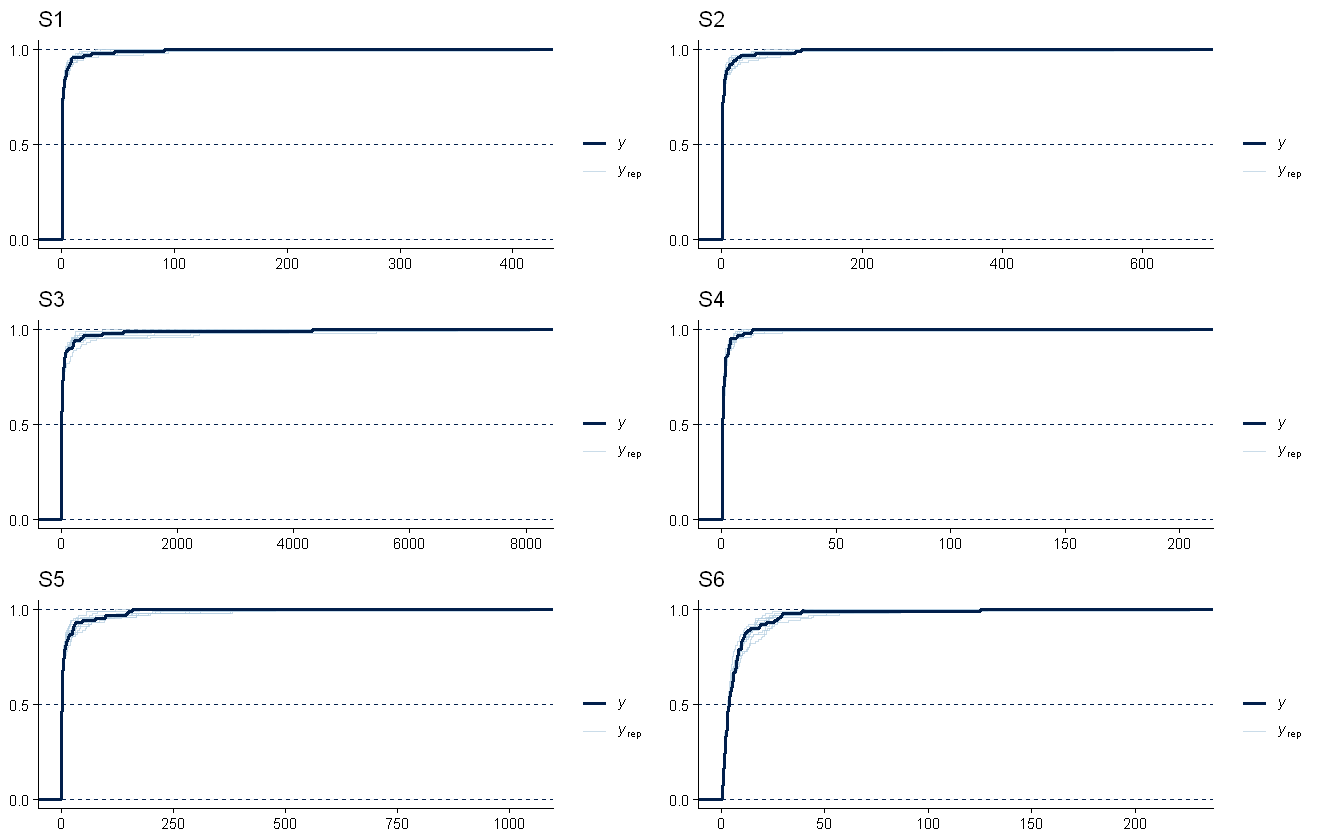

In [10]:
options(repr.plot.width = 11)
# , repr.plot.height = 7)
multi_pp_check(cens_mod, plotfun = "ecdf_overlay", discrete = TRUE)

We can see that the data are always nested within the model predictions (with the exception of the initial jumps due to the censoring, visible as the straight lines), indicating a reasonable fit to the data.

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



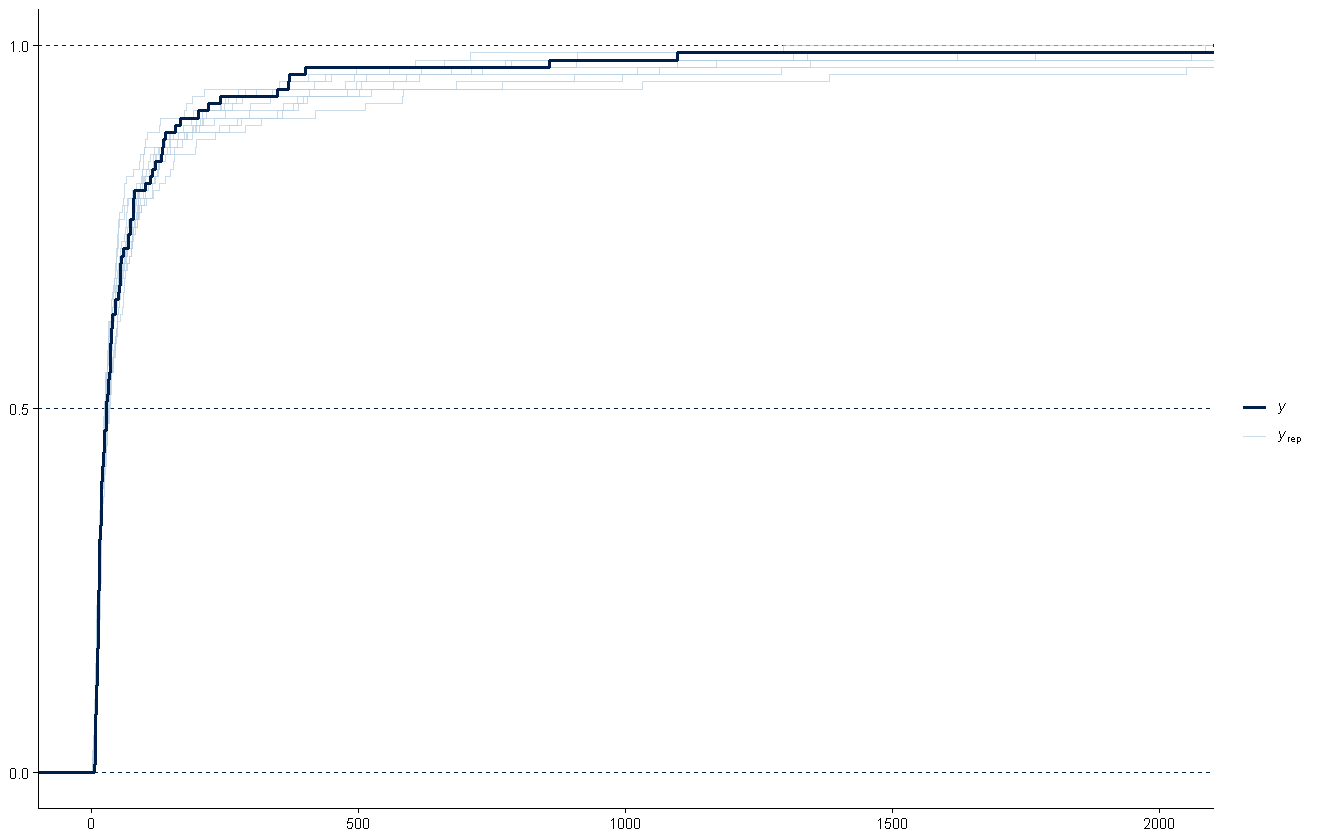

In [11]:
pp_check(cens_mod, plotfun="ecdf_overlay", discrete = TRUE) + 
  ggplot2::coord_cartesian(xlim=c(0,2000))

In this case the distribution of the overall predicted sum across all variables per site is relatively similar between the raw data and the model estimates, but in cases where more of the data is censored or just above the censoring limit this would not necessarily be true in a well-fitted model.

We can also see if the model did well at recovering the parameters used within the data simulation:

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


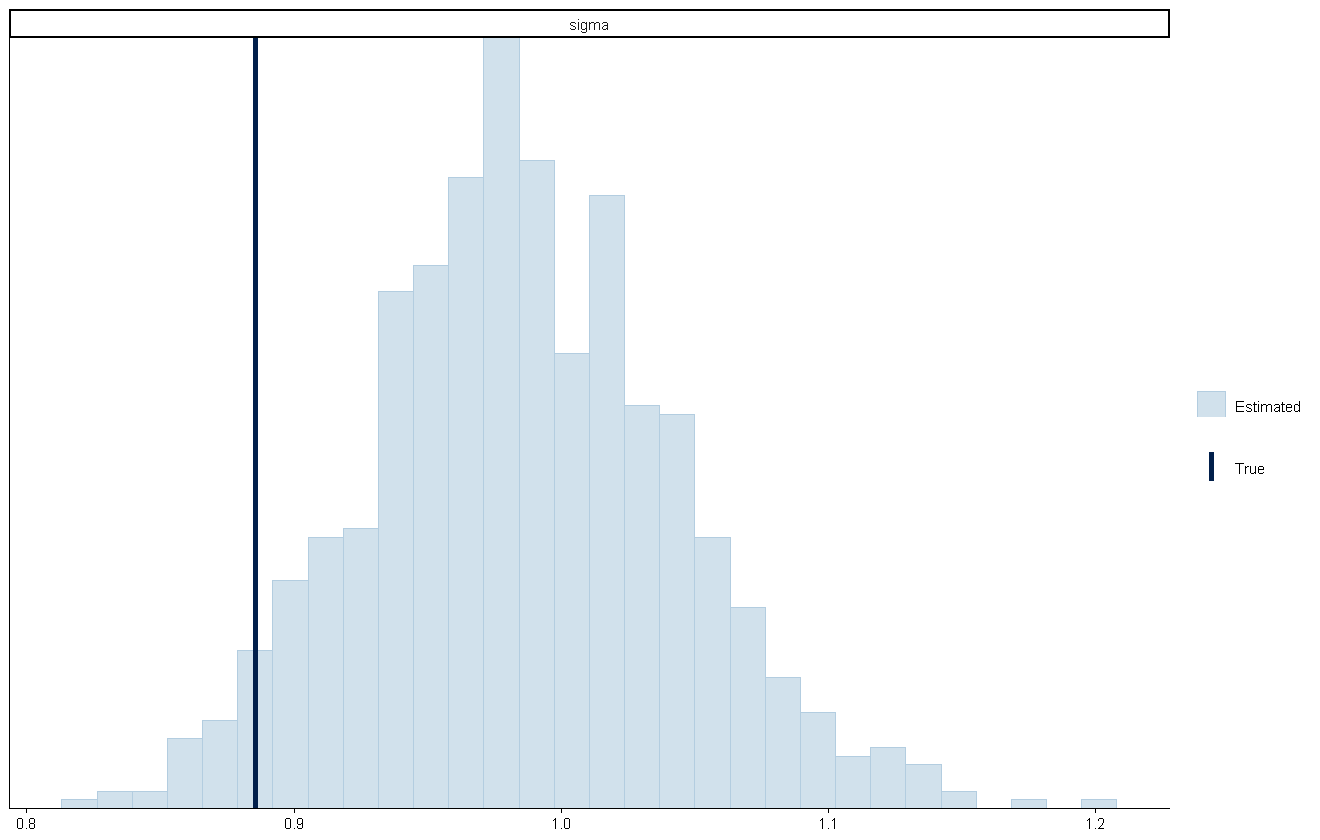

In [12]:
mcmc_plot(cens_mod, plotfun = "recover_hist", pars = "sigma",
          true = cens_dat$pars$sigma)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


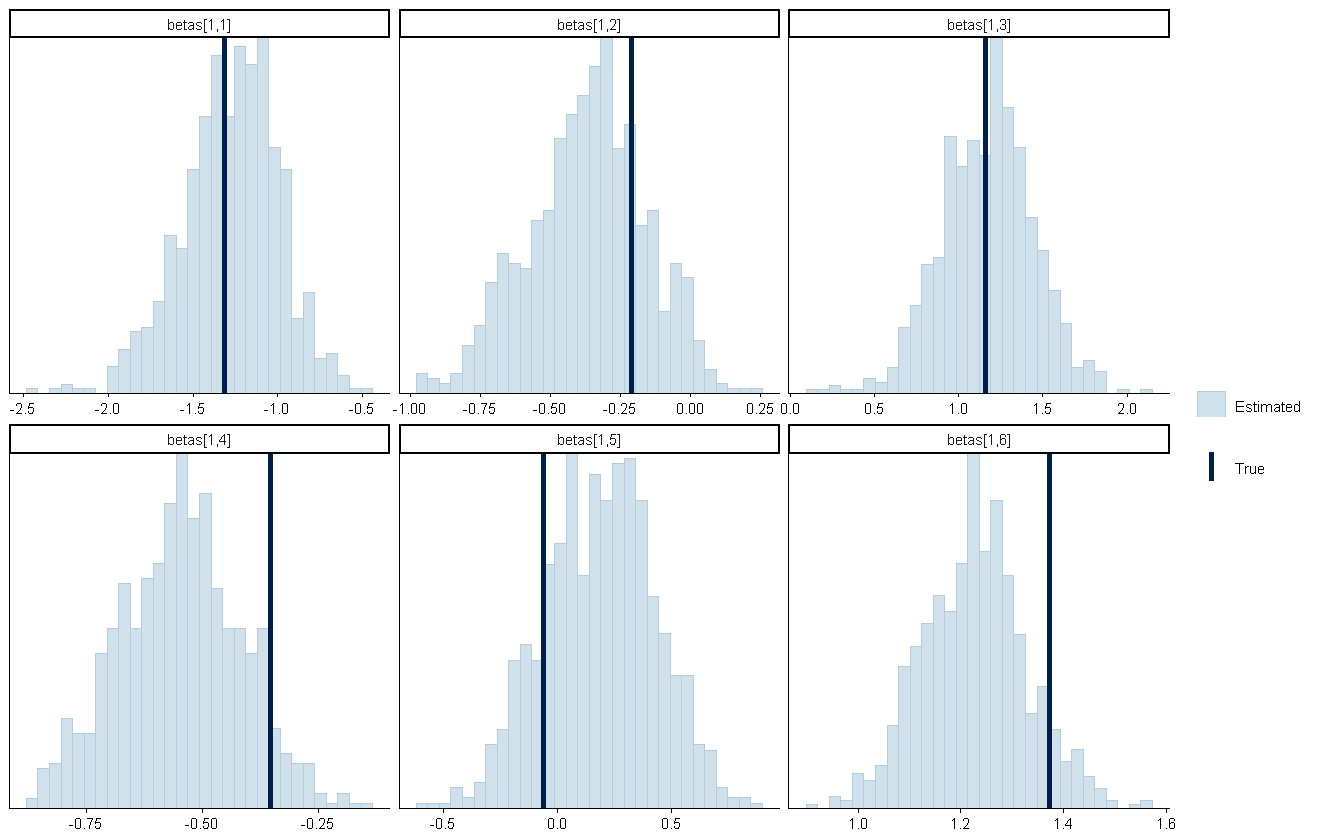

In [13]:
mcmc_plot(cens_mod, plotfun = "recover_hist", pars = paste0("betas[1,",1:6,"]"), 
          true = cens_dat$pars$betas[1,])

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


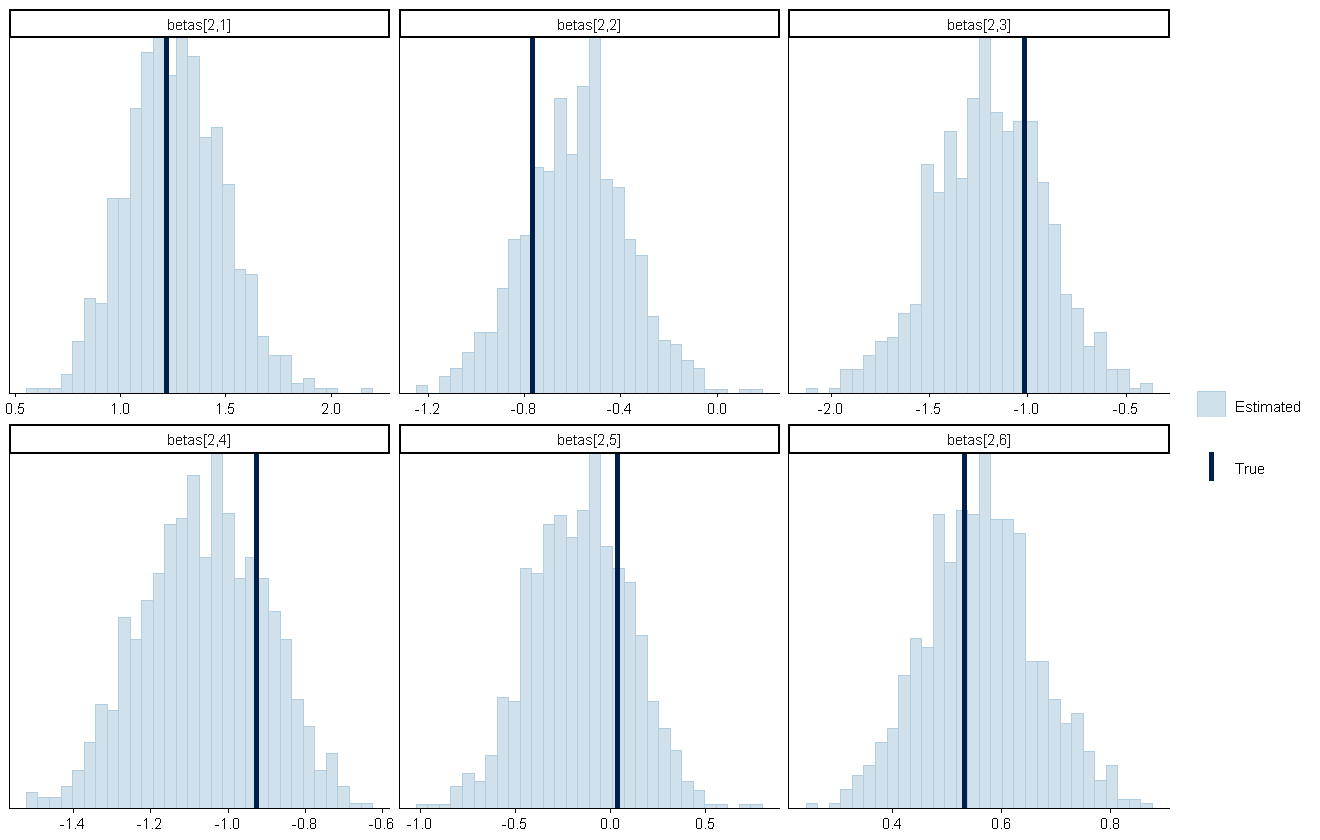

In [14]:
mcmc_plot(cens_mod, plotfun = "recover_hist", pars = paste0("betas[2,",1:6,"]"),
          true = cens_dat$pars$betas[2,])

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


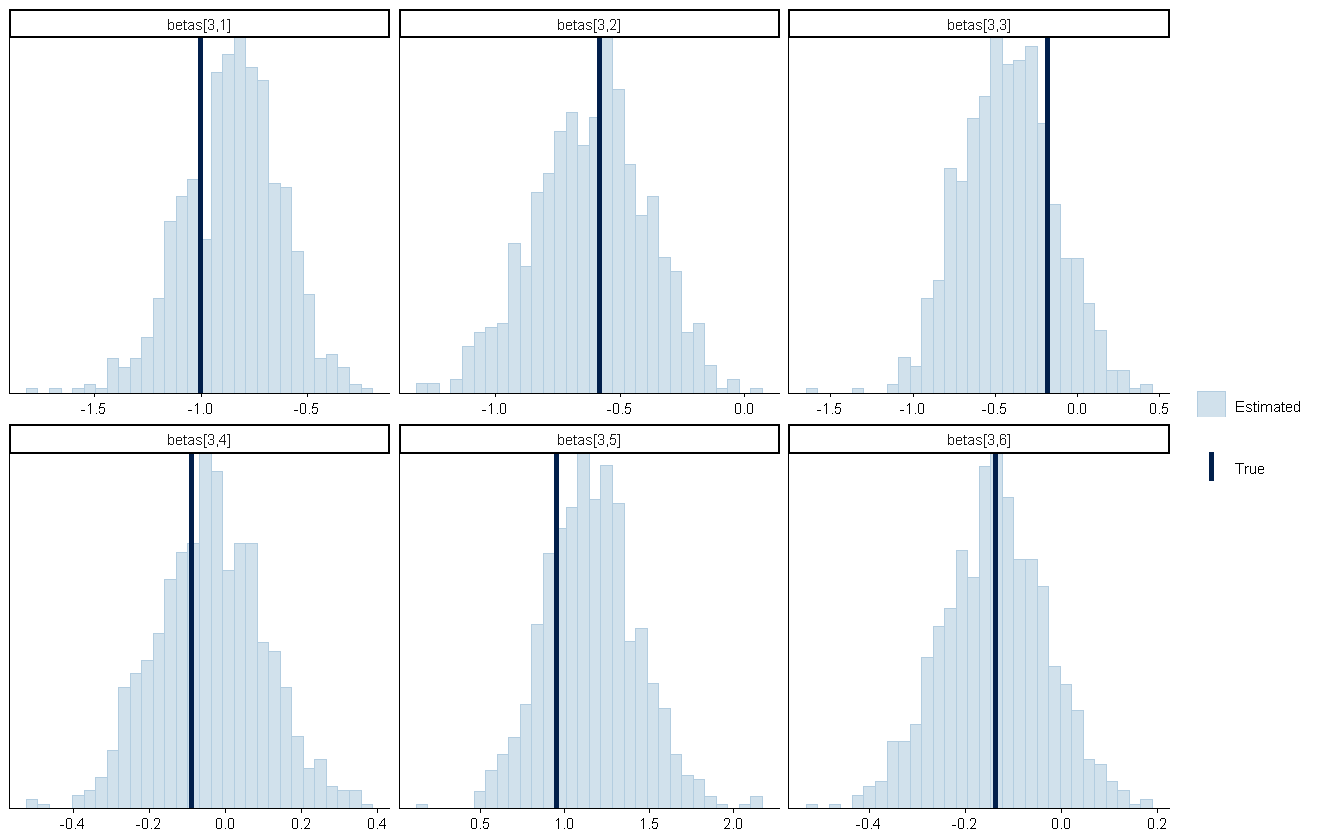

In [15]:
mcmc_plot(cens_mod, plotfun = "recover_hist", pars = paste0("betas[3,",1:6,"]"),
          true = cens_dat$pars$betas[3,])

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


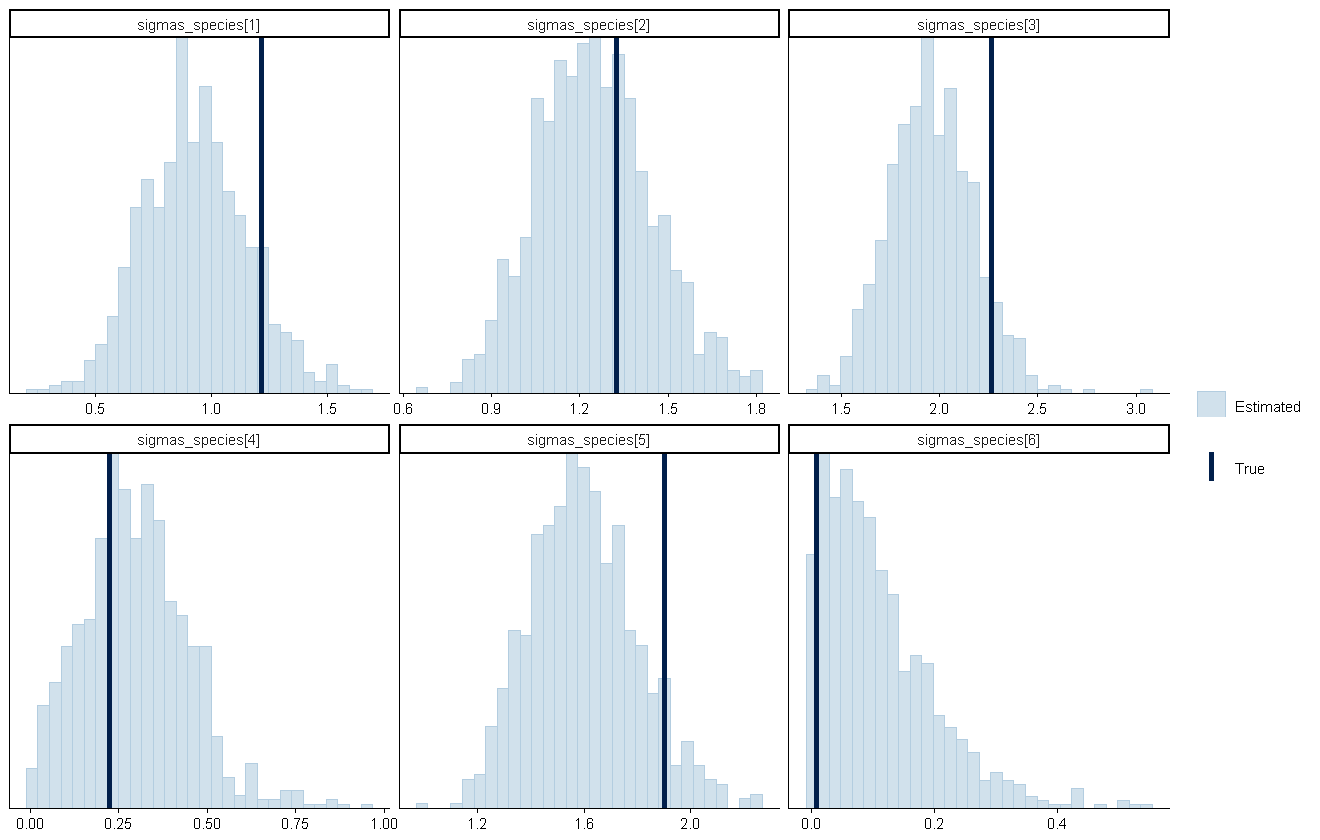

In [16]:
mcmc_plot(cens_mod, plotfun = "recover_hist", pars = paste0("sigmas_species[",1:6,"]"),
          true = cens_dat$pars$sigmas_species)

Overall the model has performed well at recovering the various parameters.

## PFAS Case Study

### Data Sources

The PFAS dataset is sourced from EA measurements on river samples, but we limited the analysis to a subset of sites that had multiple measurements over a time series to explore the ability of the splines to represent change over time. We ended up with 79 measurements over 10 sites taken within 2024. The dataset contained 16 PFAS chemicals that had been uncensored in at least 10% of all measurements, which we limited our analysis to.

In [17]:
pfas <- readRDS("Data/pfas_subset.rds")

We prepare the data, by moving it into a wide format with each chemical occupying its own column and retaining the variables that we want to use as predictors:

In [18]:
pfas_y <- pfas %>% ungroup() %>%
  select(SAMP_ID, MEAS_RESULT, MEAS_DETERMINAND_CODE,
         SAMP_SMPT_USER_REFERENCE, DATE_TIME) %>%
  pivot_wider(values_from = MEAS_RESULT, names_from = MEAS_DETERMINAND_CODE)

We limit to measurements that have values for all chemicals (i.e. no missing measurements):

In [19]:
dim(na.omit(pfas_y))

[1] 79 50

In [20]:
pfas_y <- na.omit(pfas_y)
Y <- pfas_y[, 4:50]

Create censoring matrix (1 if left-censored, 0 if not). We treat all right-censored data as uncensored:

In [21]:
cens_ID <- pfas %>% ungroup() %>%
  select(SAMP_ID, MEAS_SIGN, MEAS_DETERMINAND_CODE,SAMP_SMPT_USER_REFERENCE, DATE_TIME) %>%
  mutate(MEAS_SIGN = replace_na(ifelse(MEAS_SIGN == "<", 1, 0),0)) %>%
  pivot_wider(values_from = MEAS_SIGN, names_from = MEAS_DETERMINAND_CODE) %>%
  filter(SAMP_ID %in% pfas_y$SAMP_ID)

We now just perform some checks to make sure the censoring ID matrix has the same measurements in order and chemicals in order as the dataframe with the actual measurements:

In [22]:
all.equal(cens_ID$SAMP_ID, pfas_y$SAMP_ID)

[1] TRUE

In [23]:
all.equal(cens_ID$DATE_TIME, pfas_y$DATE_TIME)

[1] TRUE

In [24]:
all.equal(cens_ID$SAMP_SMPT_USER_REFERENCE, pfas_y$SAMP_SMPT_USER_REFERENCE)

[1] TRUE

In [25]:
all.equal(colnames(cens_ID),colnames(pfas_y))

[1] TRUE

In [26]:
cens_ID <- cens_ID[,4:50]

We remove chemicals that are mostly or wholly uncensored in subset for trial model fits:

In [27]:
Y <- Y[, colSums(cens_ID)<72]
cens_ID2 <- cens_ID[, colSums(cens_ID)<72]
cens_ID2 <- as.matrix(cens_ID2)

We add columns that give time as number of days since 1st January 2024 and sample location as a factor, to allow the splines to be set up correctly:

In [28]:
pfas_y$DATE_TIME2 <- (as.numeric(pfas_y$DATE_TIME) - 1704067201)/60/60/24
pfas_y$samp_location <- as.factor(pfas_y$SAMP_SMPT_USER_REFERENCE)

Now we plot the data to show how the trend over time varies by sampling location:

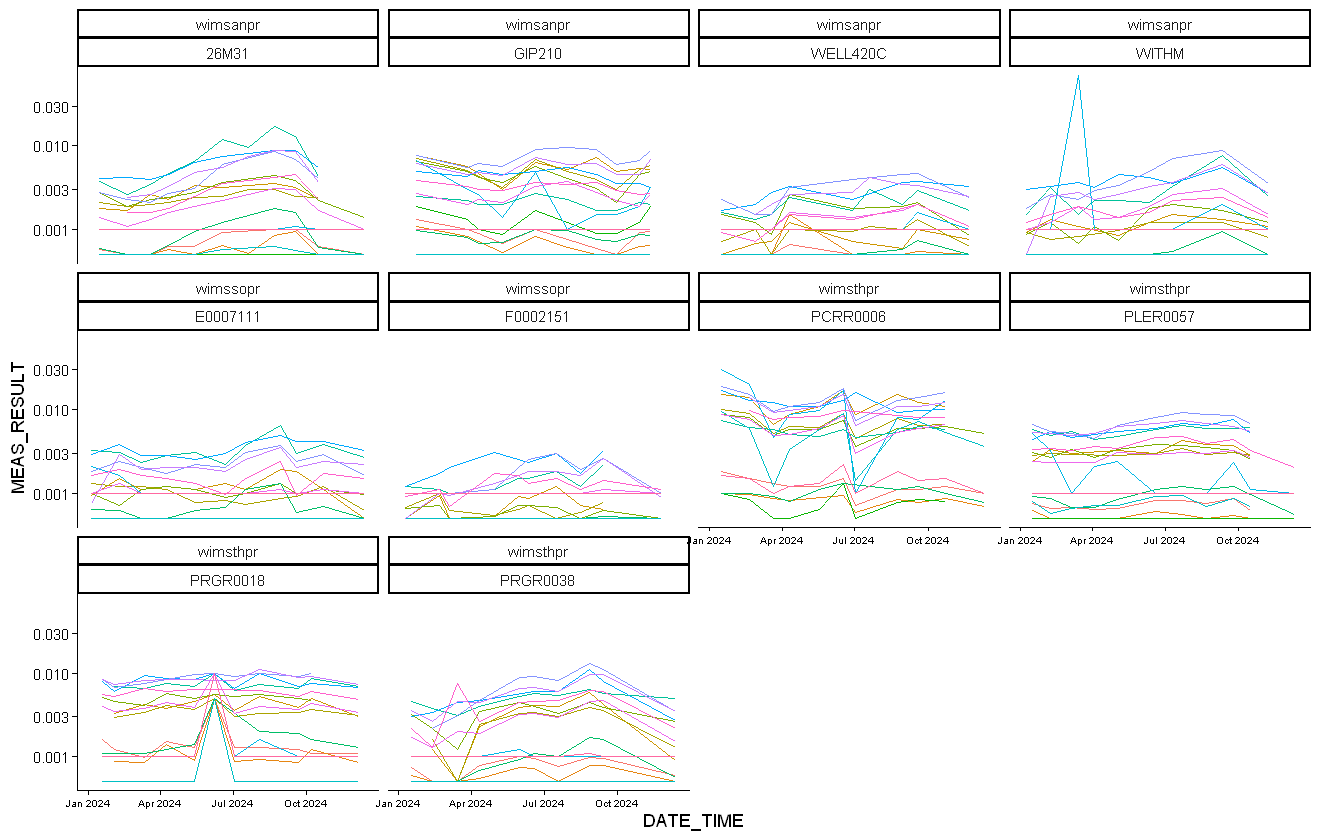

In [29]:
pfas %>%
  filter(MEAS_DETERMINAND_CODE %in% colnames(Y)) %>% 
  ggplot(aes(x = DATE_TIME, y = MEAS_RESULT, 
                 colour = MEAS_DETERMINAND_CODE)) +
  geom_line() + scale_y_log10() +
  facet_wrap(~wims_region + SAMP_SMPT_USER_REFERENCE) +
  theme(legend.position = "none",
        axis.text.x = element_text(size = 6))

`The trends in PFAS chemicals over time`

### Model fit

The model is fit using factor-smooth of time over sampling location, allowing the non-linear effect to vary by sampling location. We adapt the priors to allow for the intercepts being quite low (so the betas parameters are centred around -6 on the log-scale but with a heavy-tail), and the smoothing parameter sp being more constrained than the default. We also have a very tightly constrained prior on the sigma parameter, as initial testing revealed this could be problematic for convergence. We have set the sigma prior to constrain the parameter to within the range where most of the initial model (with weakly informative priors) found it to be. Due to the constraints of needing to save the model object in a smaller form so it doesn’t need to run each time this notebook renders, we also thin the chains considerably.

In [30]:
# pfas_mod <- stan_jsdm(~s(DATE_TIME2, samp_location, bs = "fs"),
#                       data = pfas_y, Y = Y,
#                       prior = jsdm_prior(betas = "student_t(3,-6,1)",
#                                          sp = "normal(0,1)",
#                                          sigma = "normal(0.05,0.01)"),
#                       method = "mglmm", family = "lognormal",
#                       censoring = "left", cens_ID = cens_ID2, cores = 4,
#                       control = list(adapt_delta = 0.95), thin = 10)

In [31]:
pfas_mod <- readRDS("Data/pfas_mod.rds")

First, let’s check the model performance statistics:

In [32]:
pfas_mod

Family: lognormal 
 With parameters: sigma 
Model type: mglmm
  Number of species: 16
  Number of sites: 79
  Number of predictors: 0

Model run on 4 chains with 4000 iterations per chain (2000 warmup).

Parameters with Rhat > 1.01, or Neff/N < 0.05:
                            mean      sd      15%      85%  Rhat Bulk.ESS
z_species[3,16]            1.805   0.727    1.039    2.576 1.012      719
z_species[5,16]            0.112   1.097   -1.095    1.273 1.020      434
z_species[7,65]           -0.678   0.672   -1.382   -0.012 1.010      437
z_species[8,22]            1.988   0.611    1.349    2.646 1.011      828
z_species[15,39]          -0.767   0.923   -1.713    0.182 1.013      652
cor_species_chol[11,5]    -0.101   0.220   -0.328    0.132 1.013      606
cor_species_chol[13,11]    0.150   0.157   -0.017    0.308 1.012      567
cor_species_chol[14,5]    -0.052   0.227   -0.291    0.187 1.014      490
sigma                      0.053   0.006    0.047    0.059 1.014      217
cor_speci

A couple of problematic parameters are highlighted, which isn’t great but the ESS is okay for our purposes - note also that the unthinned model fit fine, but we can’t include that here due to file size limits.

Warning message:
"Dropped 1 NAs from 'new_rhat(rhat)'."
Warning message:
"Dropped 1 NAs from 'new_neff_ratio(ratio)'."
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


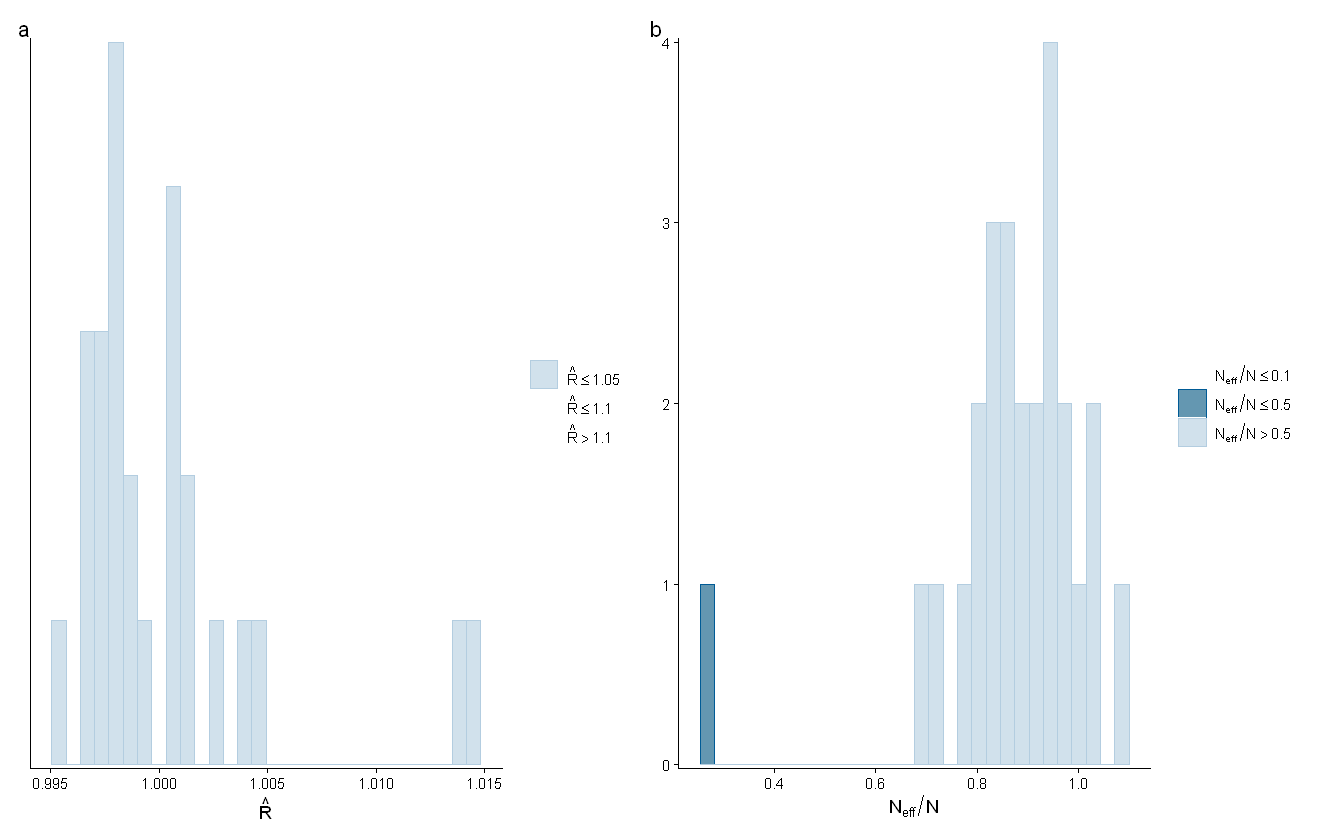

In [33]:
p1 <- mcmc_plot(pfas_mod, plotfun = "rhat_hist")
p2 <- mcmc_plot(pfas_mod, plotfun = "neff_hist")
p1 + p2 + plot_annotation(tag_levels = "a")

`The distribution of Rhat values (a) and ESS values (b) for the PFAS model`

While there are a few more parameters with low Neff/N ratios, the total sample size is still high enough that we should be okay for the analyses we are doing.

Model performance in terms of fit to the data can be assessed graphically using posterior predictive checks, i.e. we predict data with the model and then compare to the original data used to fit the model. We can do this on a chemical by chemical basis using `multi_pp_check`, or by comparing summary statistics using `pp_check`.

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



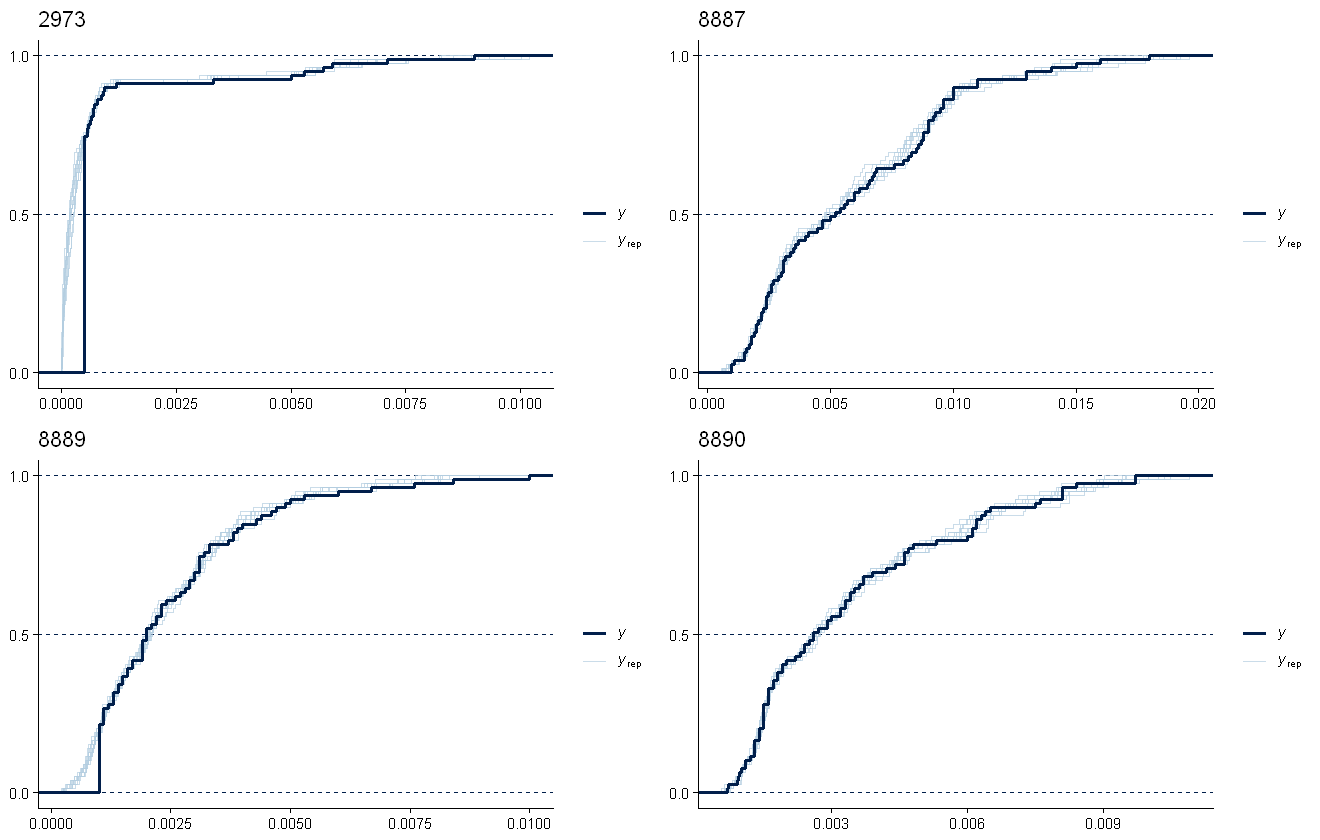

In [34]:
multi_pp_check(pfas_mod, plotfun = "ecdf_overlay", species = 1:4, discrete = TRUE)

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



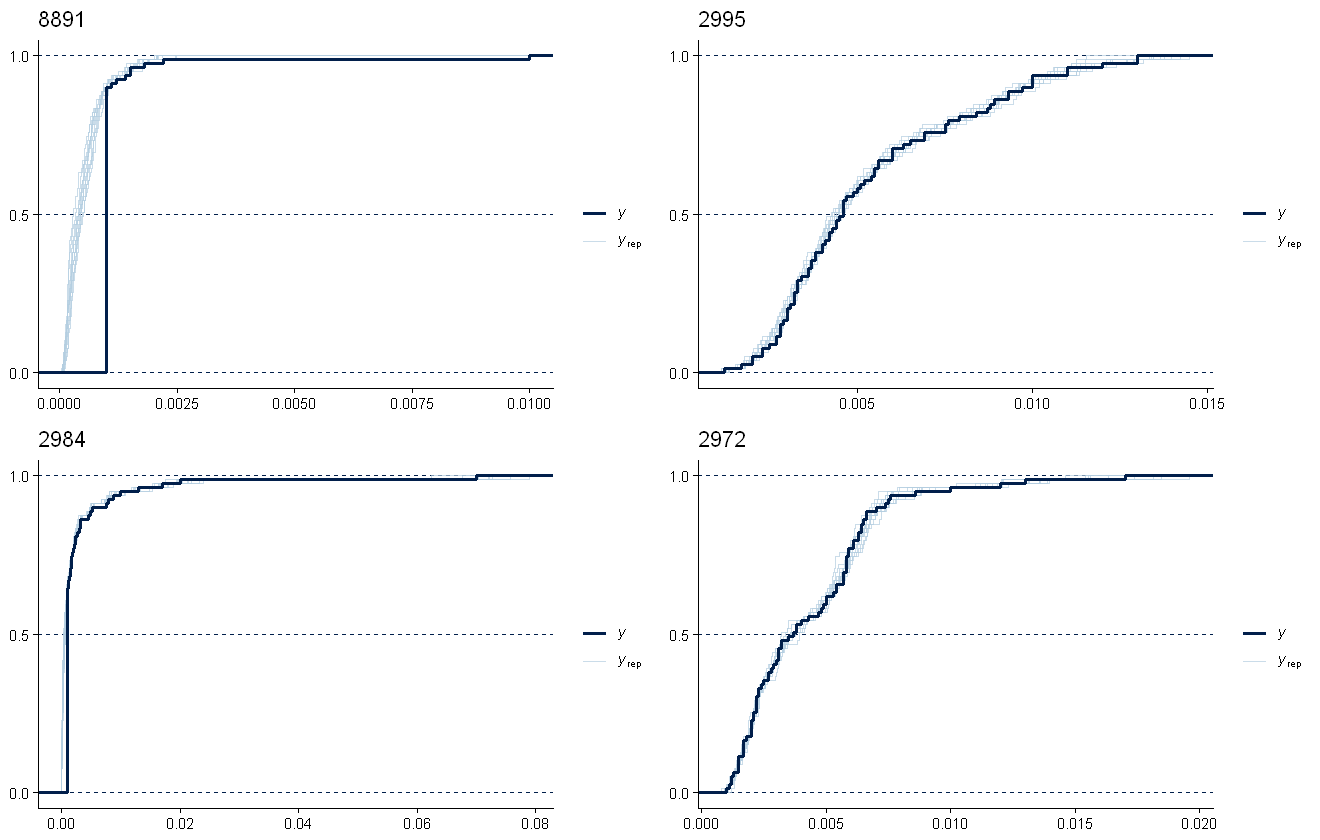

In [35]:
multi_pp_check(pfas_mod, plotfun = "ecdf_overlay", species = 5:8, discrete = TRUE)

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



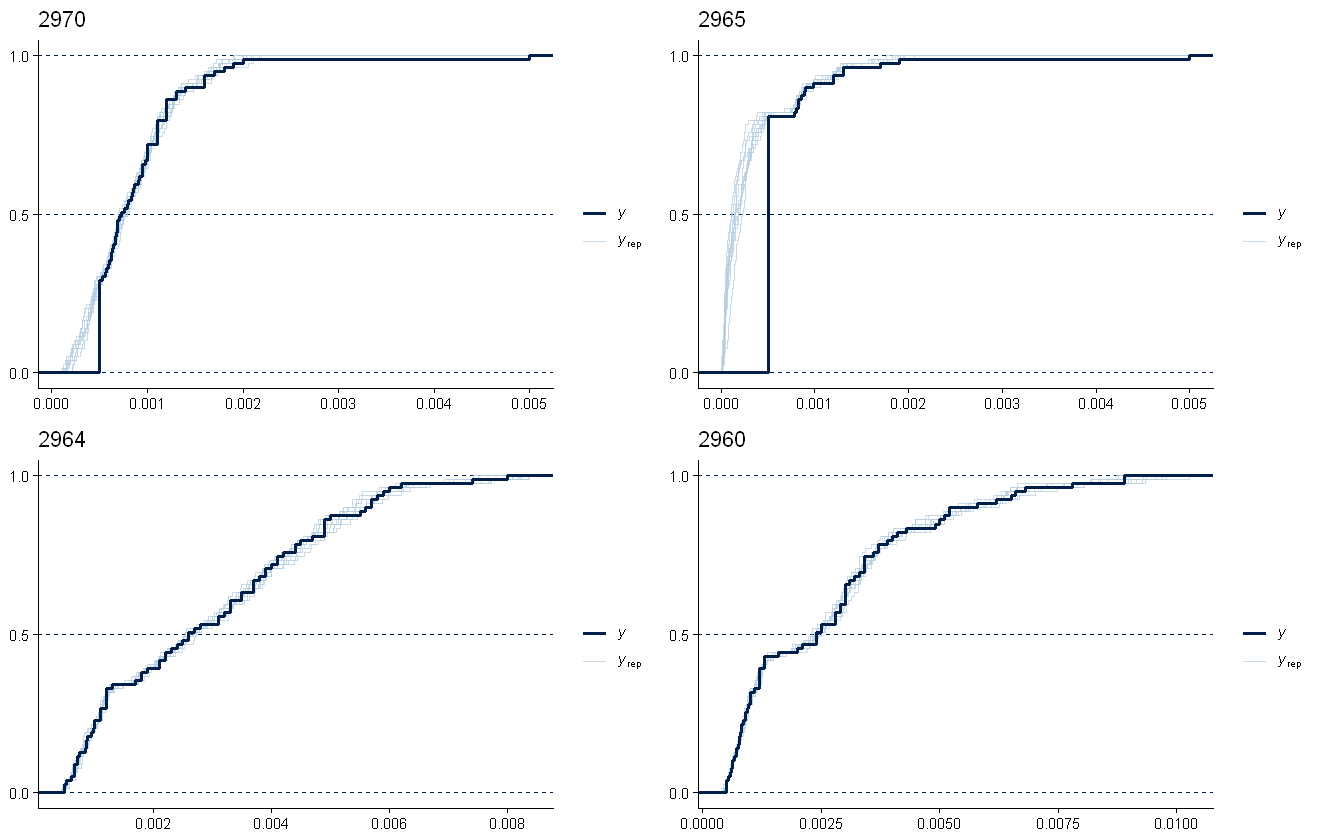

In [36]:
multi_pp_check(pfas_mod, plotfun = "ecdf_overlay", species = 9:12, discrete = TRUE)

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



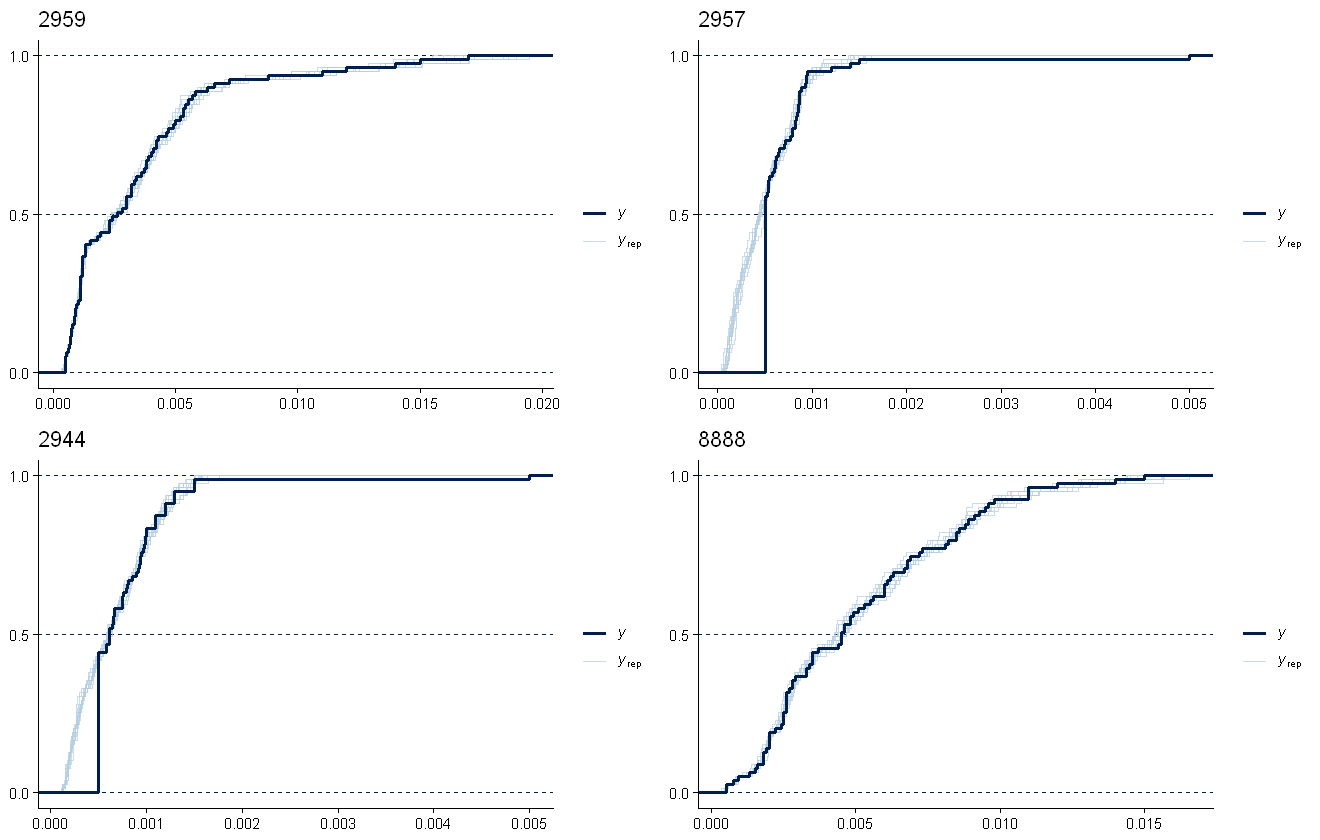

In [37]:
multi_pp_check(pfas_mod, plotfun = "ecdf_overlay", species = 13:16, discrete = TRUE)

This fits the data pretty well, the lags due to censoring are noticeable in all several in the chemical but as the model predictions are assuming no lags, that works out fine.

If we’re interested in overall summaries, such as the total PFAS value predicted, we can use the pp_check function. The default is to calculate sums over the rows of the model predictions, equivalent to calculating the predicted total PFAS chemical concentrations per row. This can be changed to calculate any summary statistic over either the rows or columns of the data. Note that this will not match the raw data, as the raw data contains within it the censoring and the predictions are assuming no censoring:

Using 10 posterior draws for ppc plot type 'ppc_dens_overlay' by default.

Warning message:
"The following arguments were unrecognized and ignored: discrete"


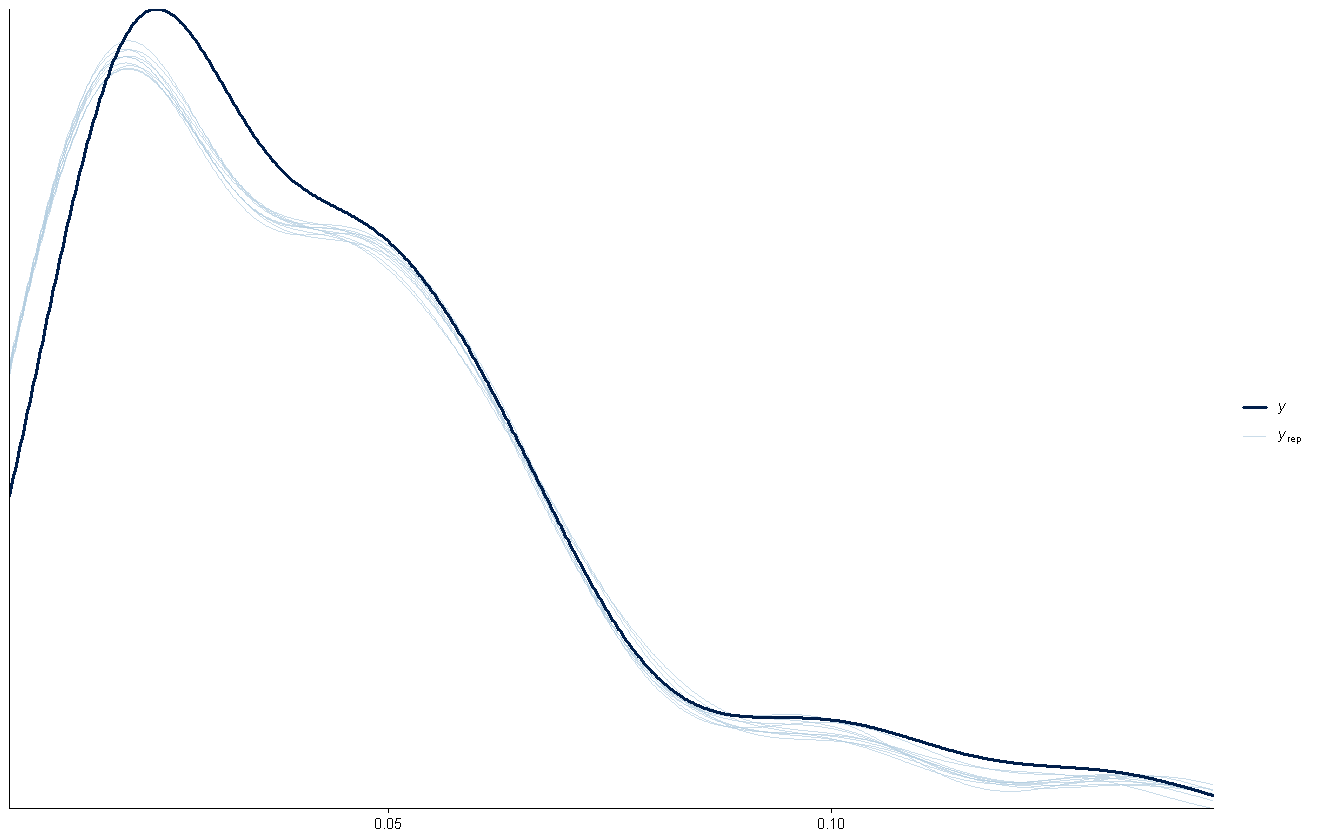

In [38]:
pp_check(pfas_mod, discrete = TRUE)

`Model- and data- estimated distribution of total PFAS concentration. Actual data shown in dark blue line, draws from the model shown as light blue lines.`

If you want the predicted value of total PFAS concentration, you can access that using `jsdm_statsummary` which runs `posterior_predict` in the background to come up with the prediction by chemical and then sum them together. By default this runs using all draws, and returns a matrix where every row is a draw from the model and every column is a measurement point. The default is also to return on the scale of the linear predictor, which is the log-scale for a lognormal so this needs to be changed to return values on the prediction scale. This function could be used to give interval estimates for total chemical concentration.

In [39]:
totalchem <- jsdm_statsummary(pfas_mod, post_type = "predict")
summary(totalchem[,1:4])

       V1                V2                V3                V4         
 Min.   :0.04710   Min.   :0.02871   Min.   :0.01847   Min.   :0.02594  
 1st Qu.:0.04940   1st Qu.:0.03074   1st Qu.:0.01960   1st Qu.:0.02794  
 Median :0.05018   Median :0.03131   Median :0.01995   Median :0.02843  
 Mean   :0.05021   Mean   :0.03130   Mean   :0.01996   Mean   :0.02846  
 3rd Qu.:0.05099   3rd Qu.:0.03187   3rd Qu.:0.02032   3rd Qu.:0.02896  
 Max.   :0.05386   Max.   :0.03422   Max.   :0.02156   Max.   :0.03111  

We can also look at the predicted effects of each predictor. The fixed effects (in this case only the intercepts) can be explored using the `envplot` function:

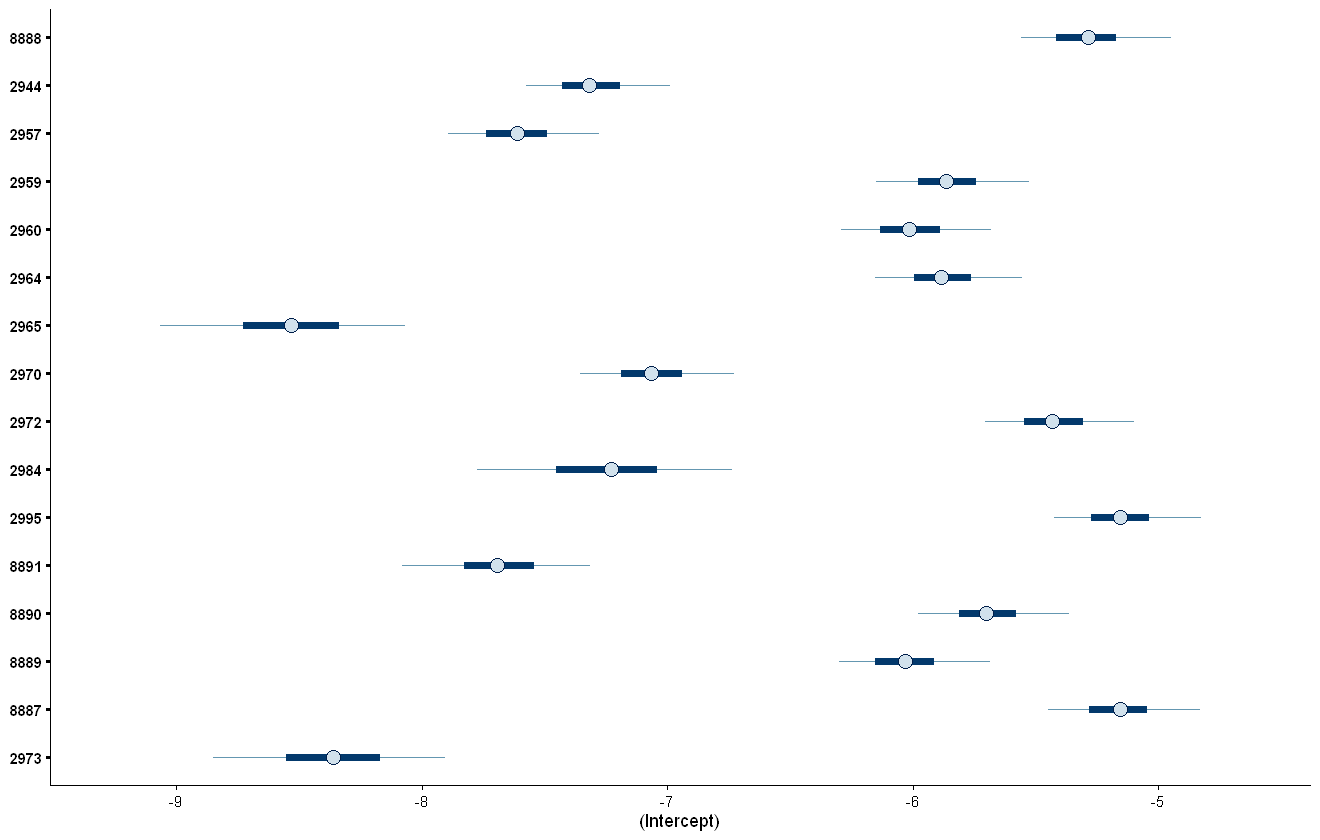

In [40]:
envplot(pfas_mod, include_intercept = TRUE)

`Model-estimated intercepts of the PFAS chemicals.`

As expected, these are very low due to the low concentrations of PFAS chemicals usually present. If the numeric values are of interest, then the `summary` function can be used to get the actual values:

In [41]:
summary(pfas_mod, pars = "betas")

,mean,sd,15%,85%,Rhat,Bulk.ESS,Tail.ESS
"betas[1,1]",-8.363,0.292,-8.651,-8.065,1.004,531,691
"betas[1,2]",-5.151,0.188,-5.336,-4.974,1.004,484,644
"betas[1,3]",-6.022,0.187,-6.201,-5.840,1.002,497,643
"betas[1,4]",-5.689,0.187,-5.868,-5.510,1.003,494,643
"betas[1,5]",-7.688,0.232,-7.922,-7.461,1.000,535,640
"betas[1,6]",-5.145,0.188,-5.325,-4.966,1.002,488,616
"betas[1,7]",-7.247,0.316,-7.577,-6.942,1.001,617,703
"betas[1,8]",-5.419,0.190,-5.613,-5.227,1.003,504,629
"betas[1,9]",-7.057,0.192,-7.249,-6.864,1.002,508,638
"betas[1,10]",-8.545,0.309,-8.847,-8.235,0.999,656,775


The spline effects can be explored using the `smoothplot` function. As smoothplot returns a list of plots (one for each spline in the model), we only call the first element of it for simplicity:

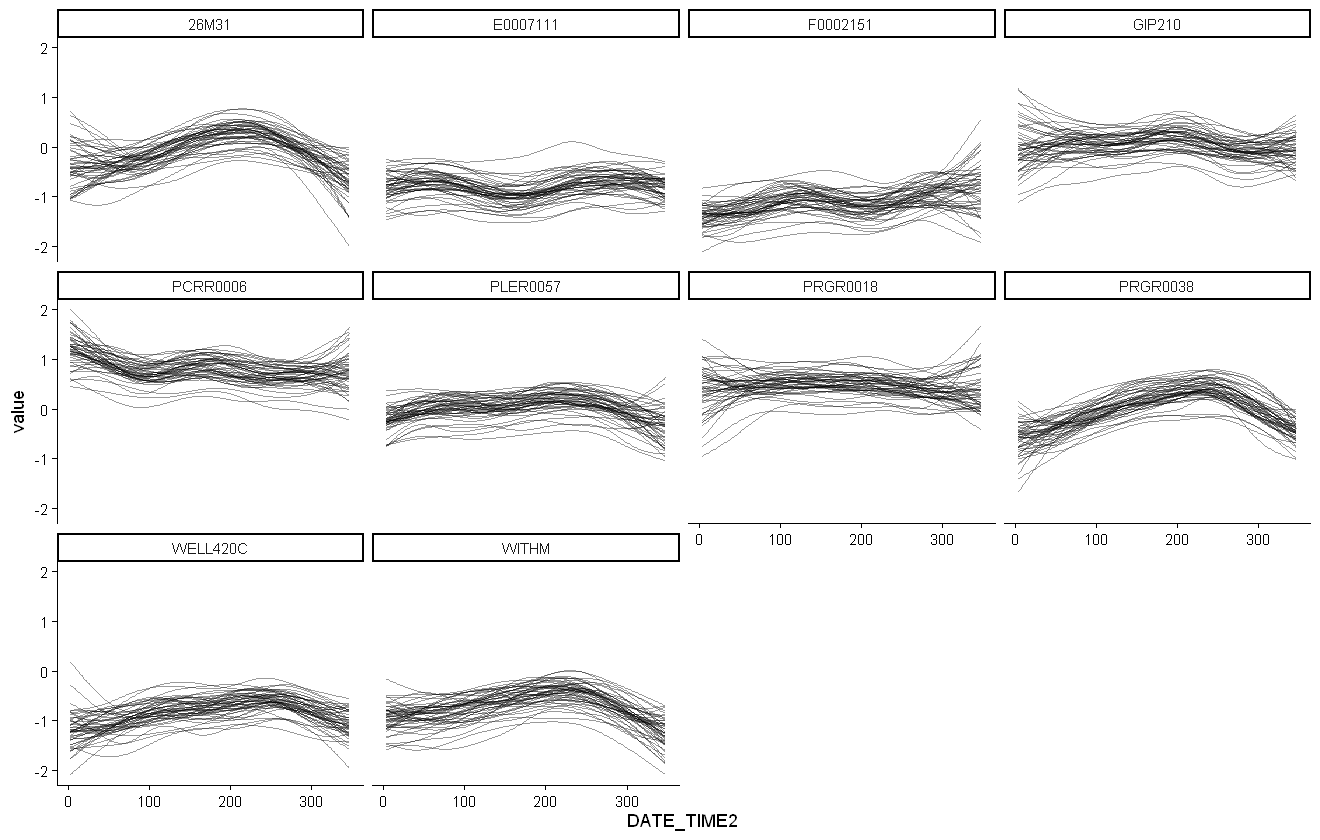

In [42]:
smoothplot(pfas_mod, ndraws = 50)[[1]]

`Plot of the estimated smooth effects of time per sampling location within the PFAS model, given as 50 random draws from the model.`

The correlation between chemicals can be plotted using the `corrplot` function:

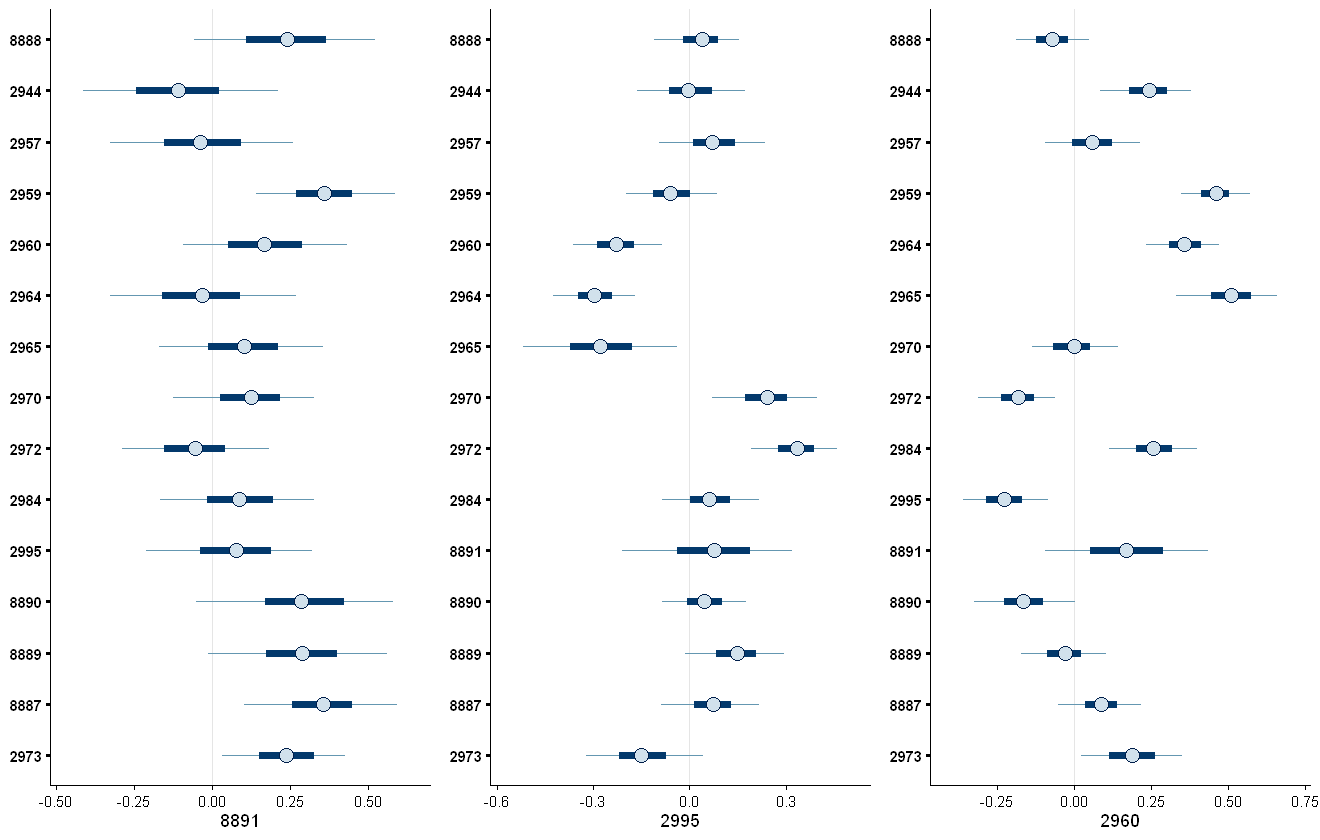

In [43]:
corrplot(pfas_mod, species = c("8891","2995","2960"))

`Plot of the model-estimated correlation between each chemical and the other chemicals. For graphical simplicity, we only plot subplots for three of the chemicals chosen at random: 8891 (PFnonncAcid); 2995 (PFBA); and 2960 (PFOS (B)).`

## PAH case study

### Data Sources

For the PAH case study, we have EA measurements that were taken on the Severn estuary between January 2015 to April 2017. This resulted in 196 measurements across 9 sites. Four PAH chemicals were measured during this period at all sites, with varying degrees of censoring. In total 339 measurements were left-censored, more often within the earlier part of the time series. There were a number of right-censored measurements as well (110), however unfortunately jsdmstan cannot currently deal with this and so we treat right-censored measurements as uncensored.

Here we read in the subset of the data as described above:

In [44]:
pah_data <- readRDS("Data/pah_data.rds")

We then reformat the data into a wide format where each chemical appears as its own column and each row represents a measurement point in time and space. We do this twice, once with the actual numbers of the measurements and once with a representation of whether the measurement was left censored. We also double check that we end up with the same rows across both. This follows the same pattern as described above within the PFAS case study.

In [45]:
pah_df <- pah_data %>% 
  select(-MEAS_SIGN) %>%
  pivot_wider(names_from = MEAS_DETERMINAND_CODE, values_from = MEAS_RESULT,
              names_prefix = "PAH")
pah_df <- na.omit(pah_df)

cens_ID_pah <- pah_data %>%
  select(-MEAS_RESULT) %>%
  mutate(MEAS_SIGN = replace_na(ifelse(MEAS_SIGN == "<", 1, 0),0)) %>%
  pivot_wider(names_from = MEAS_DETERMINAND_CODE, values_from = MEAS_SIGN,
              names_prefix = "PAH")%>%
  filter(SAMP_ID %in% pah_df$SAMP_ID)

all.equal(cens_ID_pah$SAMP_ID, pah_df$SAMP_ID)

[1] TRUE

In [46]:
all.equal(cens_ID_pah$DATE_TIME, pah_df$DATE_TIME)

[1] TRUE

We take a quick look at the data using some exploratory plots, including site location and number of censored measurements over time.

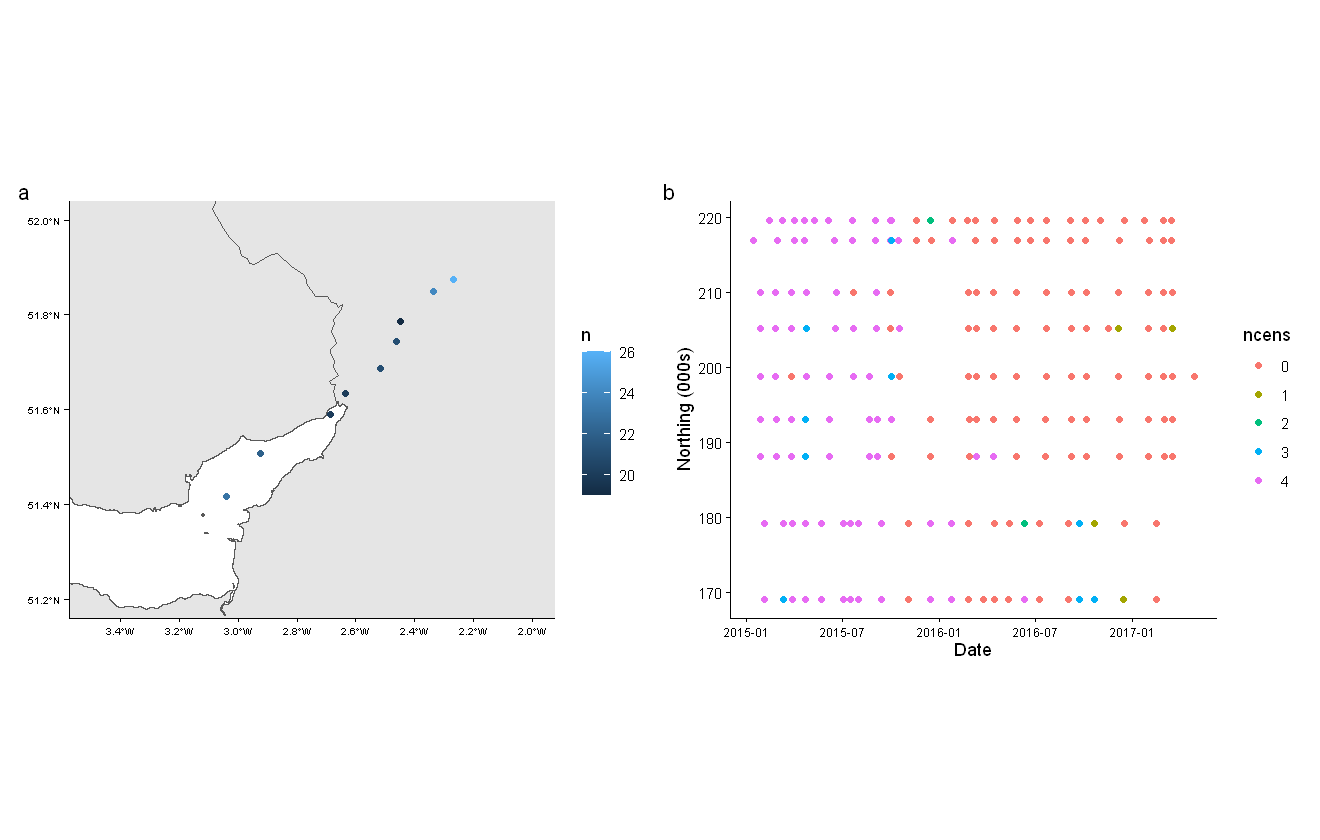

In [47]:
pas_sf <- pah_df %>%
  count(SMPT_EASTING, SMPT_NORTHING, SMPT) %>%
  st_as_sf(coords = c("SMPT_EASTING","SMPT_NORTHING"),
           crs = 27700)
p1 <- ggplot() +
  geom_sf(data = gbr) +
  geom_sf(data = pas_sf, mapping = aes(colour = n))+
  coord_sf(xlim=c(-3.5,-2),ylim=c(51.2,52))  +
  theme(axis.text = element_text(size = 6))

p2 <- cens_ID_pah %>%
  mutate(ncens = as.factor(PAH0714+PAH0731+PAH0733+PAH6399),
         SMPT_NORTHING = SMPT_NORTHING/1000) %>%
  ggplot(aes(x = DATE_TIME, y = SMPT_NORTHING, colour = ncens)) +
  geom_point() +
  labs(x = "Date", y = "Northing (000s)") +
  theme(axis.text.x = element_text(size = 7))
p1+p2 + plot_annotation(tag_levels = "a")

`Locations of sampling points (a) and number of censored measurements over time per location (b).`

Get into jsdmstan format:

In [48]:
pahs_Y <- select(pah_df, starts_with("PAH"))

cens_ID_pah <- as.matrix(select(cens_ID_pah, starts_with("PAH")))
all.equal(colnames(cens_ID_pah),colnames(pahs_Y))

[1] TRUE

### Model

We specify a PAH model where every non-linear effect is shared across the different chemicals. There are three non-linear effects, the first being a spline over the location (represented by northing only), the second being a cyclic spline over day of year to capture seasonal effects, and the third being a random effect on sampling point. The first spline we fit as a factor-smooth, with the spline varying by chemical. To do this within jsdmstan we add `species` to the spline call and set `bs = "fs"`. This will sort everything under the hood, so we
don’t need to worry about including a variable in the model call that is not within the data.frame supplied.

In [49]:
# pah_mod_bychem <- stan_jsdm(~s(SMPT_NORTHING,species,bs="fs", k = 4) +
#                               s(yday, bs = "cc") +
#                               s(SMPT, bs = "re") ,
#                             data = pah_df, Y = pahs_Y,
#                             method = "mglmm", family = "lognormal",
#                             prior = jsdm_prior(sigma = "normal(0.1,0.01)",
#                                                sp = "normal(0,1)",
#                                                betas = "student_t(3,-5,1)"),
#                             censoring = "left", cens_ID = cens_ID_pah,
#                             cores = 4, thin = 5)

You’ll notice the prior on the sigma parameter is extremely tight. Due to the high degree of flexibility in the normal and lognormal families within the jsdm context, the sigma parameter sometimes proves problematic in model fitting. As such, the prior on the sigma is set based upon an earlier model fit with a weakly informative prior (normal(0,1)) where \>90% of the model fit had the sigma within the range of 0.08-0.12. In the earlier model, sigma occasionally went lower than this range for brief periods leading to convergence and sampler efficiency warnings. For the sake of this vignette, we are removing these cases where sigma drops and more variance is therefore explained by the species covariance parameters.

The other priors are equivalent to saying the intercept is around 0.01 (the beta parameters are specified on the log-scale) and constraining the smoothing parameters to be relatively low.

The model takes about 10-20 minutes to run on a windows laptop over four cores, so we are loading in the result separately:

In [50]:
pah_mod_bychem <- readRDS("Data/pah_mod_bychem.rds")

Evaluating model fit can be done by looking at fit statistics and graphical checks. If we print the model object to the (), we get a summary of the model plus it would include any parameters with high Rhat values or low effective sample size values.

In [51]:
pah_mod_bychem

Family: lognormal 
 With parameters: sigma 
Model type: mglmm
  Number of species: 4
  Number of sites: 196
  Number of predictors: 0

Model run on 4 chains with 4000 iterations per chain (2000 warmup).

No parameters with Rhat > 1.01 or Neff/N < 0.05

No problematic parameters are highlighted, which is a good start!

While the Rhat values and ESS values of every parameter can be accessed using the summary command, the high number of parameters in these models means a quicker way to check would be through calling the bayesplot package with mcmc_plot.

Warning message:
"Dropped 1 NAs from 'new_neff_ratio(ratio)'."
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


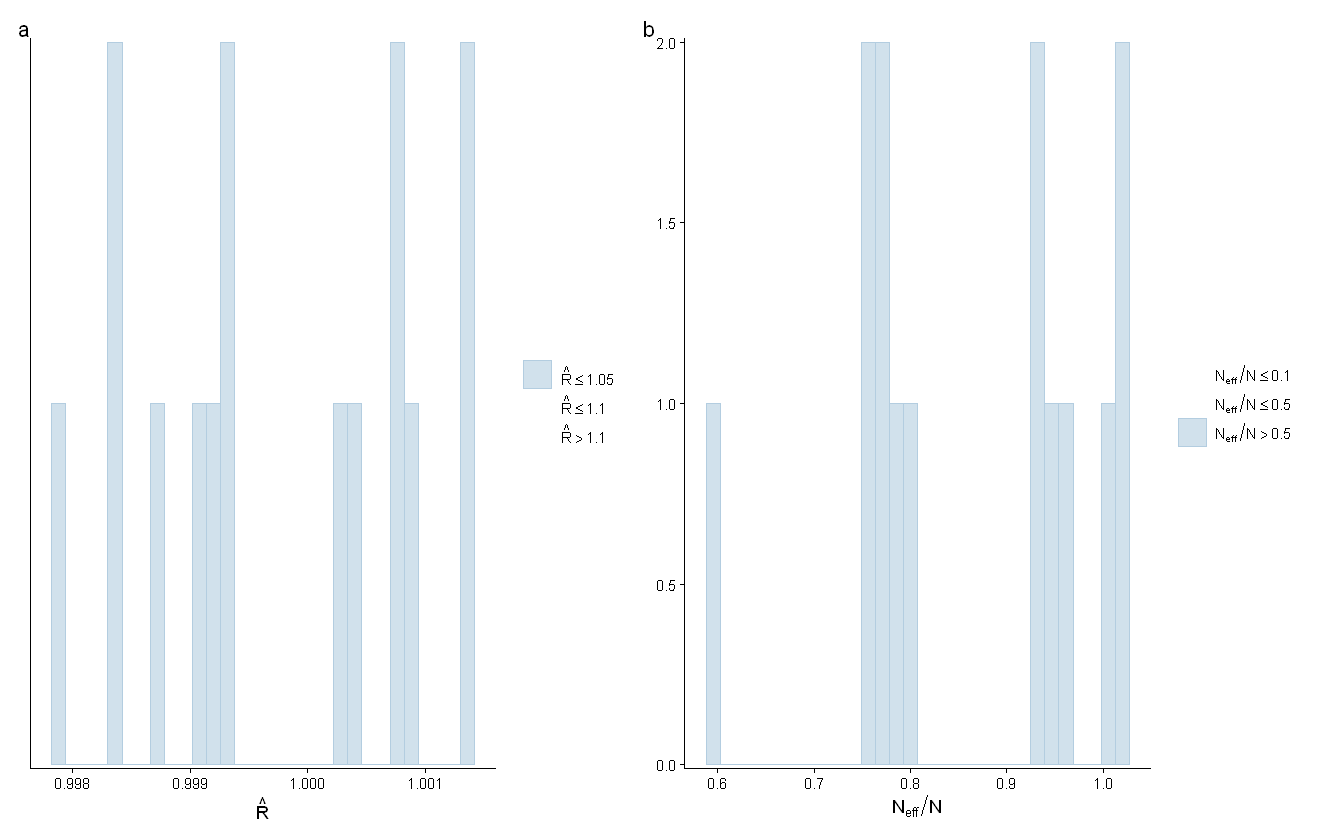

In [52]:
p1 <- mcmc_plot(pah_mod_bychem, plotfun = "rhat_hist")
p2 <- mcmc_plot(pah_mod_bychem, plotfun = "neff_hist")
p1 + p2 + plot_annotation(tag_levels = "a")

`The distribution of Rhat values (a) and ESS values (b) for the PAH model.`


While there are a few parameters with low Neff/N ratios, the total sample size is still high enough that we should be okay. There are many other potential plotting functions for looking at model fit, see bayesplot::available_mcmc() for a full list.

We can also check to see how well the data is recovered, using a posterior predictive check. Due to the censored nature of this data, we use an empirical cumulative density function overlay:

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



Warning message:
"Removed 59 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 3 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 295 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 76 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_ecdf()`)."


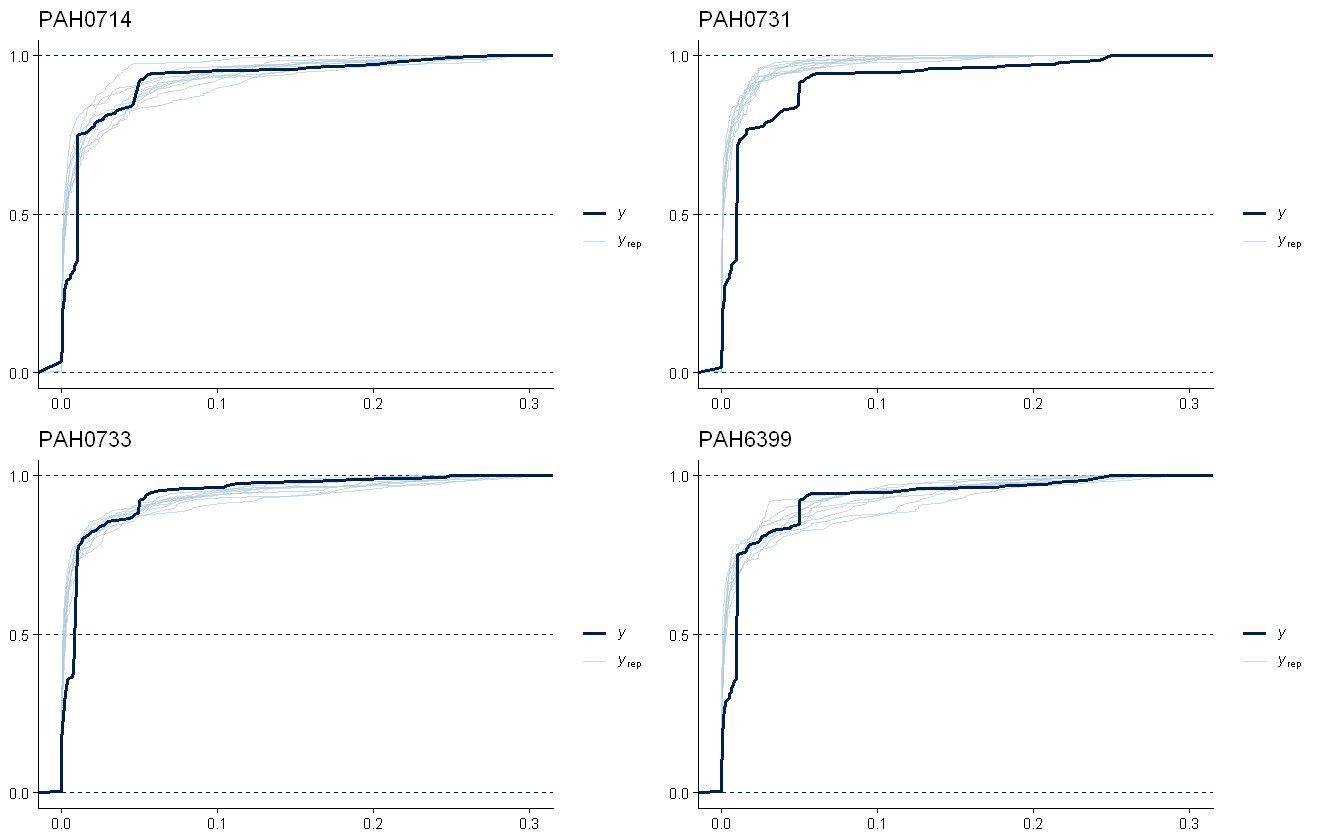

In [53]:
multi_pp_check(pah_mod_bychem, plotfun = "ecdf_overlay", xlim=  c(0,0.3))

`Ability of the PAH model to recover the raw data values per chemical. Actual data shown in dark blue line, draws from the model shown as light blue lines.`

The data recovery of the model isn’t great, with the model often overestimating the chemical concentrations present. This is due to the factor-smooth on species, unfortunately, so we are better off fitting a reduced model assuming the same responses across the chemical concentrations:

In [54]:
# pah_mod <- stan_jsdm(~s(SMPT_NORTHING, k = 4) +
#                        s(yday, bs = "cc") +
#                        s(SMPT, bs = "re") ,
#                      data = pah_df, Y = pahs_Y,
#                      method = "mglmm", family = "lognormal",
#                      prior = jsdm_prior(sigma = "normal(0.1,0.01)",
#                                         sp = "normal(0,1)",
#                                         betas = "student_t(3,-5,1)"),
#                      censoring = "left", cens_ID = cens_ID_pah,
#                      cores = 4, thin = 5)

In [55]:
pah_mod <- readRDS("Data/pah_mod.rds")

Okay, so let’s see how this model performs.

First, the model fit statistics:

In [56]:
pah_mod

Family: lognormal 
 With parameters: sigma 
Model type: mglmm
  Number of species: 4
  Number of sites: 196
  Number of predictors: 0

Model run on 4 chains with 4000 iterations per chain (2000 warmup).

No parameters with Rhat > 1.01 or Neff/N < 0.05

No problematic parameters are highlighted, which is a good start!

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


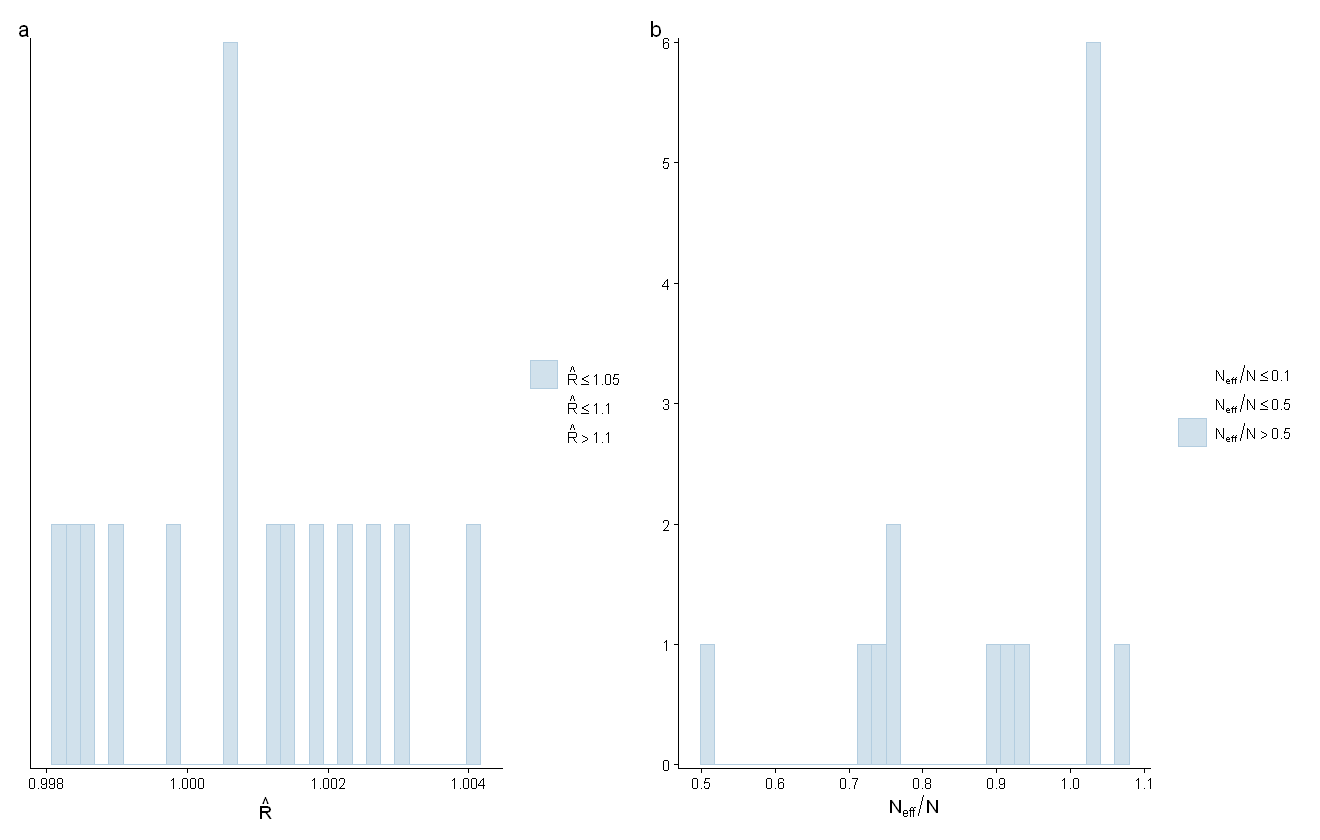

In [57]:
p1 <- mcmc_plot(pah_mod, plotfun = "rhat_hist")
p2 <- mcmc_plot(pah_mod, plotfun = "neff_hist")
p1 + p2 + plot_annotation(tag_levels = "a")

`The distribution of Rhat values (a) and ESS values (b) for the second PAH model`

This model also performs very well in that all Rhat values are well under 1.01 and the effective sample size ratio of the parameters is always greater than 0.5.

Let’s see if this model has recovered the data better:

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.

Warning message:
"Removed 30 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 3 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 23 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 11 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 1 row containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 22 rows containing non-finite outside the scale range (`stat_ecdf()`)."
Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_ecdf()`)."


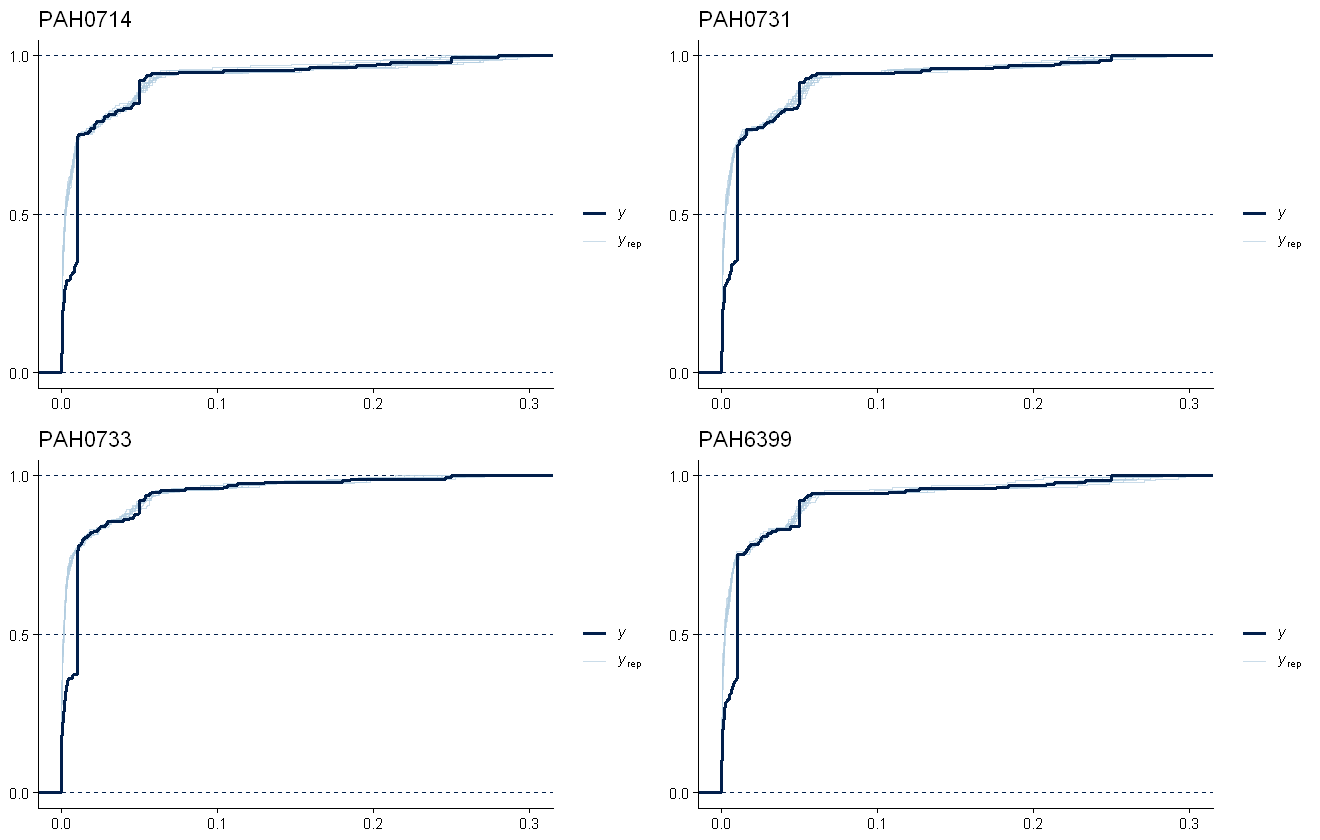

In [58]:
multi_pp_check(pah_mod, plotfun = "ecdf_overlay", discrete = TRUE, xlim = c(0,0.3))

`Ability of the second PAH model to recover the raw data values per chemical. Actual data shown in dark blue line, draws from the model shown as light blue lines.`

This is a much better fit to the data! Note that as the limits of detection varies across the time series, there is not such a clear cutoff where the LOD is present in the original data, but in the lower concentrations present we can see there are some sections where the model smooths over the jumps in the raw data. If we’re interested in overall summaries, such as the total PAH value predicted, we can use the pp_check function. Note that this will not match the raw data, as the raw data contains within it the censoring and the predictions are assuming no censoring:

Using 10 posterior draws for ppc plot type 'ppc_ecdf_overlay' by default.



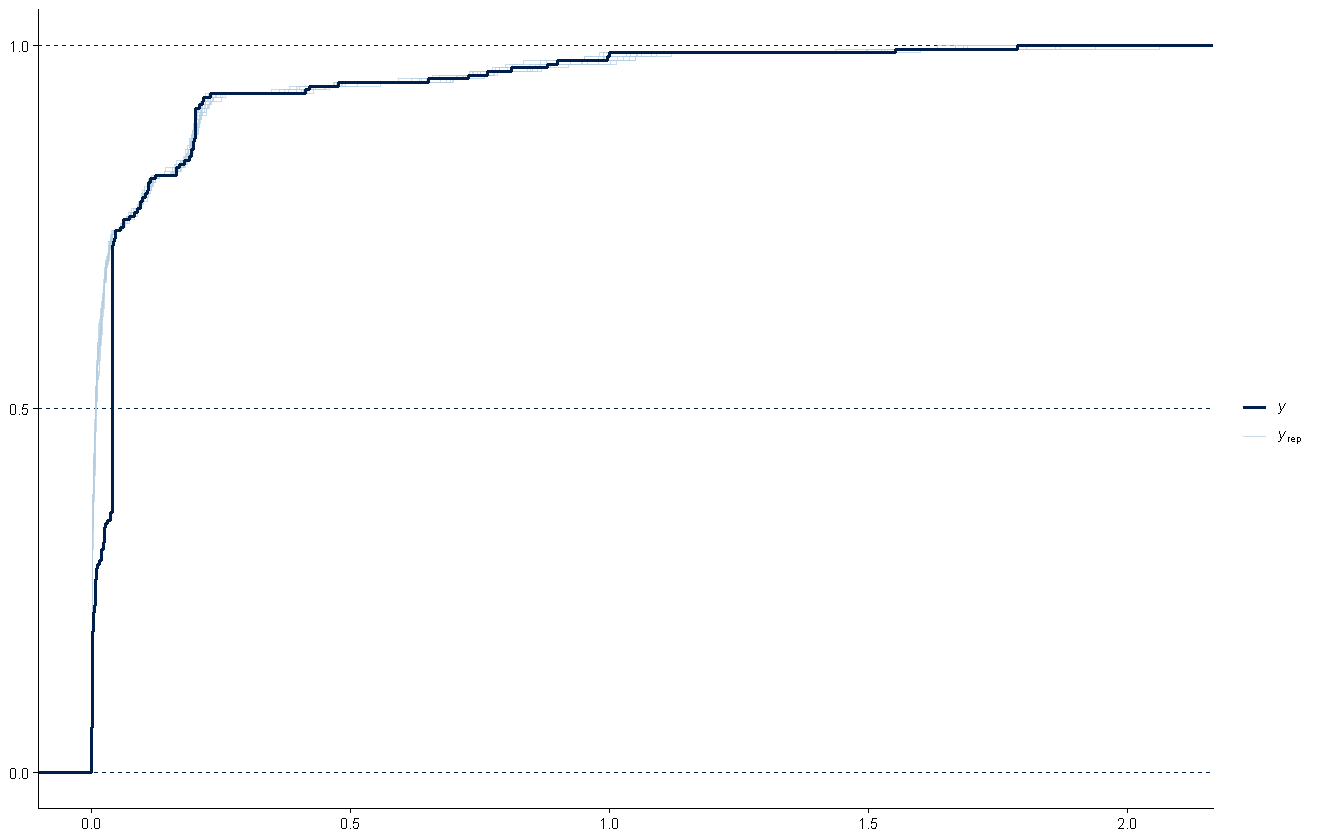

In [59]:
pp_check(pah_mod, plotfun= "ecdf_overlay", discrete = TRUE)

`Model- and data- estimated distribution of total PAH concentration. Actual data shown in dark blue line, draws from the model shown as light blue lines.`

We can also look at the predicted effects of each predictor. The fixed effects (in this case only the intercepts) can be explored using the `envplot` function:

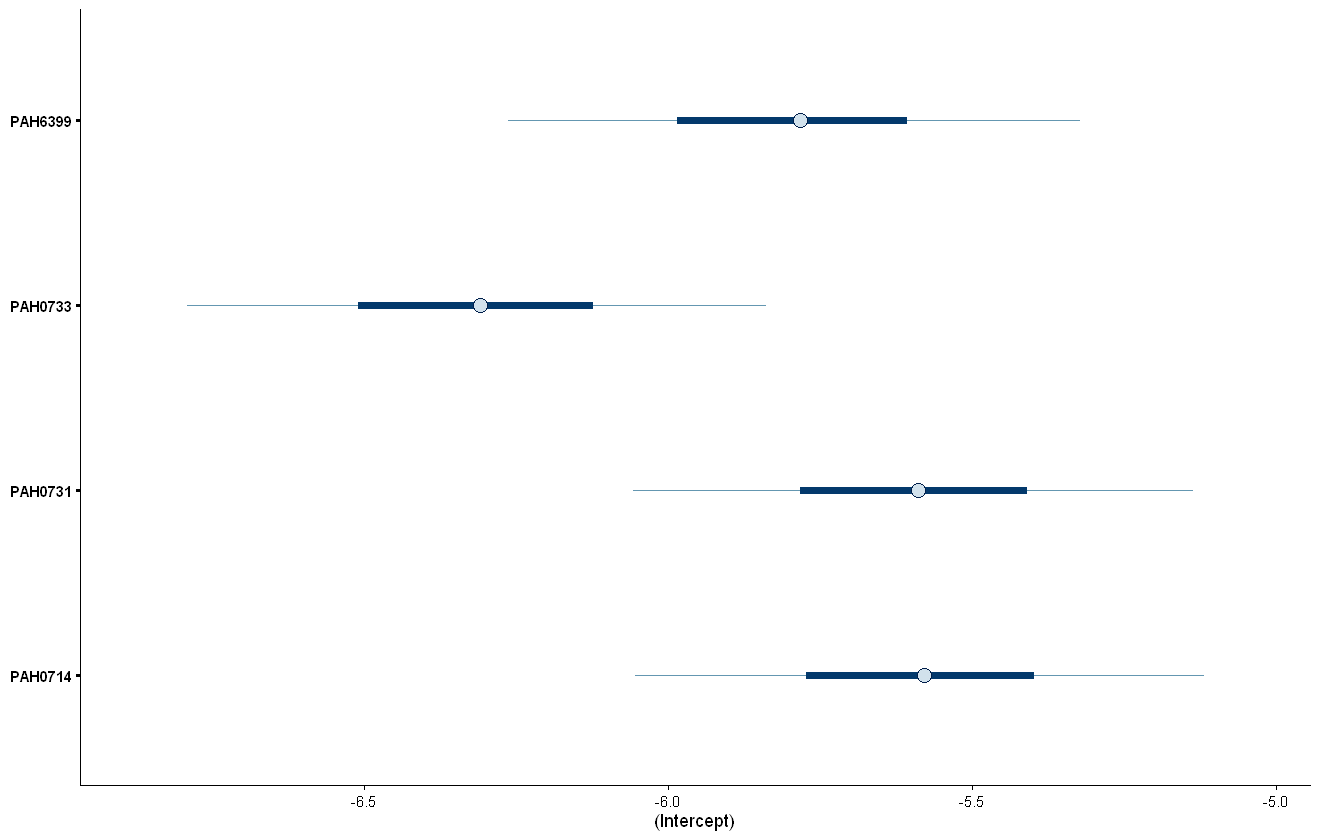

In [60]:
envplot(pah_mod, include_intercept = TRUE)

`Model-estimated intercepts of the PAH chemicals.`

The spline effects can be explored using the `smoothplot` function. As smoothplot returns a list of plots (one for each spline in the model), we wrap them up into a patchwork object:

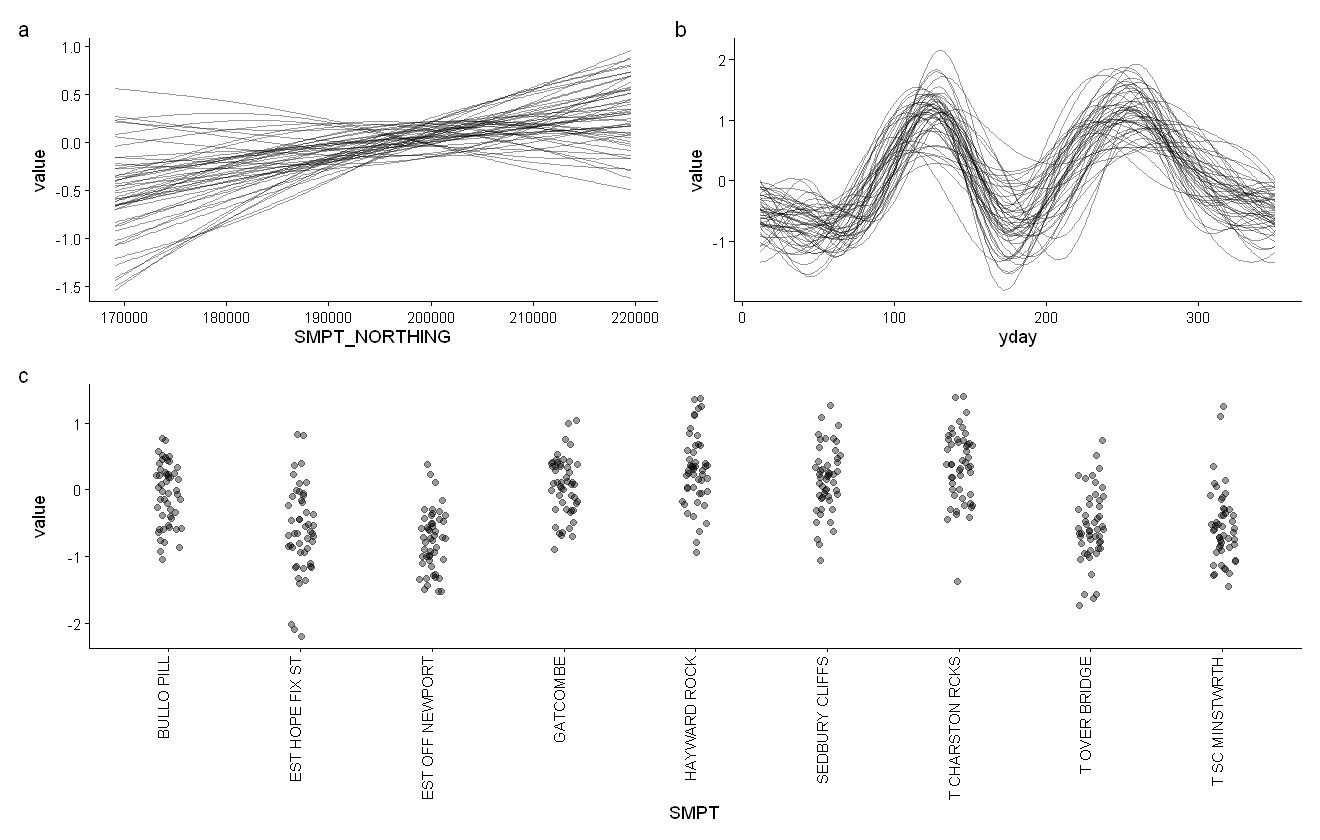

In [61]:
design <- "AB
           CC"
wrap_plots(smoothplot(pah_mod, ndraws = 50), design = design) + 
  plot_annotation(tag_levels = "a")

`Plots of the estimated smooth effects within the PAH model, given as 50 random draws from the model. The predicted change as we go north (a), the predicted change over the year (b), and deviation from the average per site (i.e. the random effects, c).`

The correlation between chemicals can be plotted using the `corrplot`
function:

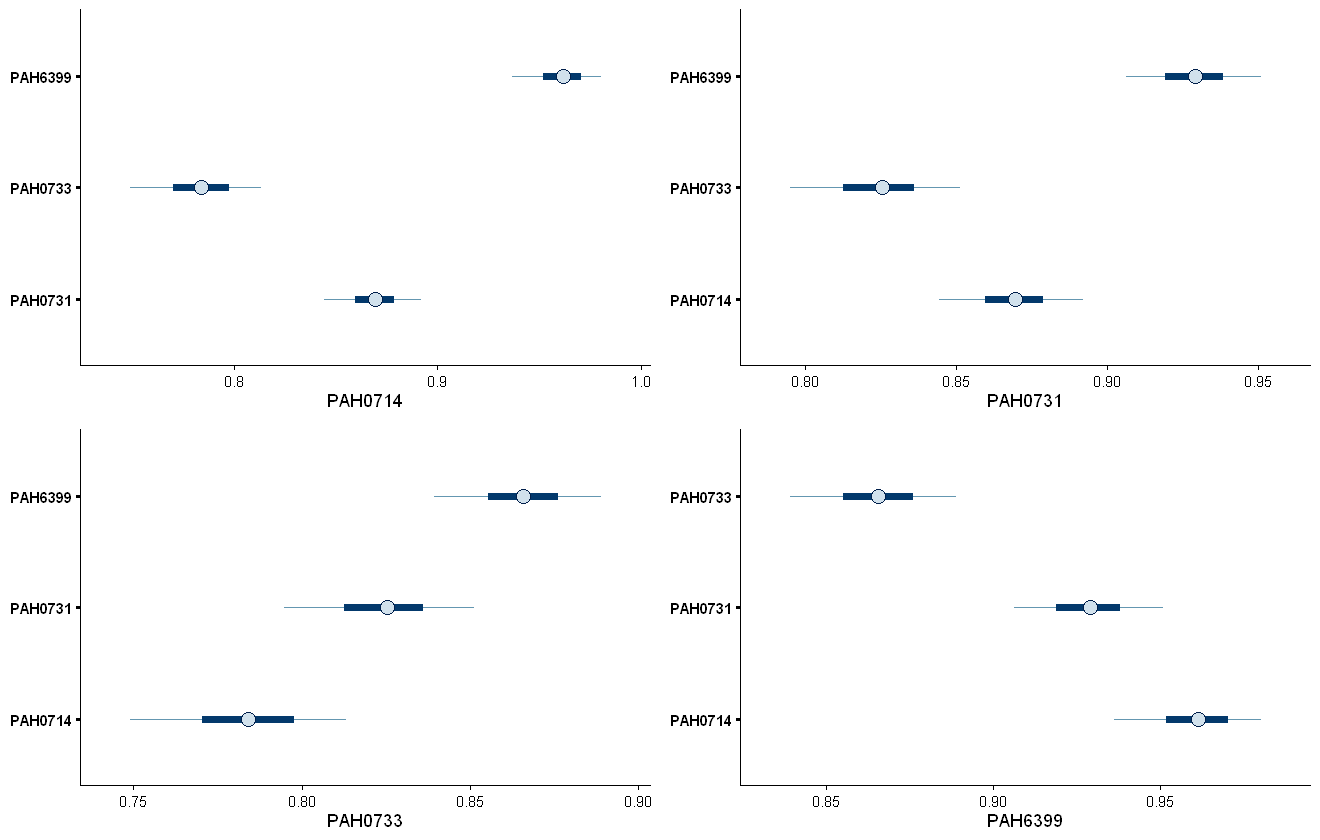

In [62]:
corrplot(pah_mod)

`Plot of the model-estimated correlation between each chemical and the other three chemicals. Note that there is repetition within this plot, i.e. PAH0714-PAH6399 appears within both the PAH0714 and PAH6399 subplots.`

# Discussion

Within this work we have demonstrated the potential for joint species distribution models to model multivariate censored water quality chemical datasets. These can lead to further insight into water quality dynamics and improve the total predictions of groups of censored water quality chemical concentrations.

The ability of a JSDM approach to improve the predictions of species depends upon the common species being a good predictor for the rarer species ([Erickson & Smith, 2023](https://doi.org/10.1111/ecog.06500)). Within our two case studies we found very different levels of residual correlation between chemicals, with PFAS chemicals showing weak to moderate correlation with each other while PAH chemicals show strong to very strong correlations with each other. The residual correlation will change based upon what data is included within the model and the model
structure, but it is worth considering which chemical groups (or subgroups) would benefit from being modelled jointly.

One concern about the models presented here is the tight prior upon the global sigma parameter (i.e. the standard deviation of the lognormal distribution) that was required to fit the models. The high degree of flexibility within the lognormal distribution means that there are multiple ways to fit the model, and the analyst needs to supply a high degree of control to achieve convergence. There may be other model parameterisations that fit this better, which could be explored in future, and, alternatively, other families such as the gamma family could be explored to see if they improve the model fitting procedure.

# Acknowledgements

This work was funded by the Department of Environment, Food and Rural Affairs, Natural Capital Ecosystem Assessment Programme. It was managed by the Environment Agency and delivered by the UK Centre for Ecology and Hydrology, under Research, Development and Evidence Framework contract RDE945.

# References

Carpenter, B., Gelman, A., Hoffman, M. D., Lee, D., Goodrich, B., Betancourt, M., Brubaker, M. A., Guo, J., Li, P., & Riddell, A. (2017). Stan: A probabilistic programming language. Journal of Statistical Software, 76(1), 1–32. https://doi.org/10.18637/jss.v076.i01

Erickson, K. D., & Smith, A. B. (2023). Modeling the rarest of the rare: A comparison between multi‐species distribution models, ensembles of small models, and single‐species models at extremely low sample sizes. Ecography, 2023(6), 861–875. https://doi.org/10.1111/ecog.06500

Miller, D. L. (2025). Bayesian views of generalized additive modelling. Methods in Ecology and Evolution, 16(3), 446–455. https://doi.org/10.1111/2041-210X.14498

Pedersen, E. J., Miller, D. L., Simpson, G. L., & Ross, N. (2019). Hierarchical generalized additive models in ecology: An introduction with mgcv. PeerJ, 7, e6876. https://doi.org/10.7717/peerj.6876

Seaton, F. (2025). jsdmstan: An R package for fitting joint species distribution models in Stan (p. 2025.11.10.687559). bioRxiv. https://doi.org/10.1101/2025.11.10.687559

Warton, D. I., Blanchet, F. G., O’Hara, R. B., Ovaskainen, O., Taskinen, S., Walker, S. C., & Hui, F. K. C. (2015). So many variables: Joint modeling in community ecology. Trends in Ecology & Evolution, 30(12), 766–779. https://doi.org/10.1016/j.tree.2015.09.007